# Engagement Prediction Analysis in WildChat

**Purpose:** Develop and validate a predictive model of user engagement (return behavior) based on first-prompt features  
**Dataset:** WildChat (4.7M conversations, 2.4M users, April 2023 – July 2025)  
**Output:** Predictive model with strict train/test separation and confirmatory validation

---

## Methodological Requirements

- **Temporal holdout**: Train on pre-cutoff data, test on post-cutoff data
- **New-user restriction**: Test set contains ONLY users whose first-ever conversation is after cutoff
- **Ablation studies**: Demonstrate incremental value of feature sets
- **Confounder control**: Word count, intent category
- **Intent diversity**: Descriptive only (not predictive due to circularity)

---

## Contents

1. **Setup and Brand Configuration**
2. **Data Loading and Temporal Overview** - Visualize data distribution, select train/test cutoff
3. **Train/Test Splits** - New-user-only test set with temporal holdout
4. **Outcome Variable** - Fixed 60-day window for return behavior
5. **Feature Extraction** - First-prompt linguistic features
6. **Intent Classification** - For confounder control
7. **Feature Matrix and Helper Functions**
8. **Ablation Study** (EXPLORATORY) - Feature set comparison on training data
9. **Random Feature Comparison** - Sanity check
10. **Permutation Importance** - Feature importance analysis
11. **Final Model Training** - Train on full training set
12. **CONFIRMATORY TEST** - Evaluate on held-out test set (run ONCE)
13. **Intent Diversity** (Descriptive) - Characterize engaged users
14. **Model-Version Sensitivity** - Test within model families
15. **Limitations and Recommendations**
16. **Output Summary**


In [3]:
# ============================================================
# Setup & Brand Configuration
# ============================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from scipy import stats
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output directory
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# =============================================================================
# PHRONOS BRAND COLORS (Light Mode)
# =============================================================================
BRAND = {
    'paper': '#F2F0E9',           # Primary background
    'ink': '#1A1A1A',             # Primary text/axes
    'gold': '#B08D55',            # Accent, highlights, signal
    'gold_dim': 'rgba(176, 141, 85, 0.12)',
    'faded': 'rgba(26, 26, 26, 0.5)',      # Secondary text
    'faded_light': 'rgba(26, 26, 26, 0.08)', # Borders, dividers
    'white': '#FFFFFF',           # Card backgrounds
    'alert': '#CC5544',           # Critical, errors (used for toxic)
    'success': '#44AA77',         # Positive states
}

# Convert rgba strings to matplotlib-compatible format
def rgba_to_tuple(rgba_str):
    """Convert 'rgba(r,g,b,a)' string to matplotlib tuple."""
    match = re.match(r'rgba\((\d+),\s*(\d+),\s*(\d+),\s*([\d.]+)\)', rgba_str)
    if match:
        r, g, b, a = match.groups()
        return (int(r)/255, int(g)/255, int(b)/255, float(a))
    return rgba_str

FADED = rgba_to_tuple('rgba(26, 26, 26, 0.5)')
FADED_LIGHT = rgba_to_tuple('rgba(26, 26, 26, 0.08)')

# =============================================================================
# MATPLOTLIB CONFIGURATION
# =============================================================================
plt.rcParams.update({
    # Figure
    'figure.facecolor': BRAND['paper'],
    'figure.edgecolor': BRAND['ink'],
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.facecolor': BRAND['paper'],
    'savefig.edgecolor': 'none',
    
    # Axes
    'axes.facecolor': BRAND['paper'],
    'axes.edgecolor': BRAND['ink'],
    'axes.labelcolor': BRAND['ink'],
    'axes.titlecolor': BRAND['ink'],
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'axes.axisbelow': True,
    
    # Grid
    'grid.color': FADED_LIGHT,
    'grid.linewidth': 0.5,
    'grid.alpha': 1.0,
    
    # Ticks
    'xtick.color': BRAND['ink'],
    'ytick.color': BRAND['ink'],
    'xtick.labelcolor': BRAND['ink'],
    'ytick.labelcolor': BRAND['ink'],
    
    # Text
    'text.color': BRAND['ink'],
    
    # Font - Use Fira Code for labels, fallback to monospace
    'font.family': 'monospace',
    'font.monospace': ['Fira Code', 'Consolas', 'Monaco', 'monospace'],
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    
    # Legend
    'legend.facecolor': BRAND['white'],
    'legend.edgecolor': BRAND['ink'],
    'legend.framealpha': 1.0,
})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_phronos_style(ax, title=None, xlabel=None, ylabel=None):
    """Apply Phronos brand styling to an axes object."""
    ax.set_facecolor(BRAND['paper'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BRAND['ink'])
    ax.spines['bottom'].set_color(BRAND['ink'])
    ax.tick_params(colors=BRAND['ink'], which='both')
    ax.grid(True, alpha=0.3, color=BRAND['ink'], linewidth=0.5)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', color=BRAND['ink'])
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=BRAND['ink'])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=BRAND['ink'])

def save_figure(fig, name, tight=True):
    """Save figure with Phronos styling."""
    path = f'../outputs/figures/pub_{name}.png'
    if tight:
        fig.savefig(path, dpi=300, bbox_inches='tight', 
                    facecolor=BRAND['paper'], edgecolor='none')
    else:
        fig.savefig(path, dpi=300, facecolor=BRAND['paper'], edgecolor='none')
    print(f"Saved: {path}")
    return path

print("Phronos brand configuration loaded.")
print(f"  Paper: {BRAND['paper']}")
print(f"  Ink: {BRAND['ink']}")
print(f"  Gold: {BRAND['gold']}")
print(f"  Random state: {RANDOM_STATE}")


Phronos brand configuration loaded.
  Paper: #F2F0E9
  Ink: #1A1A1A
  Gold: #B08D55
  Random state: 42


Loading data...
Loaded 4,743,336 conversations
Unique users: 2,462,800

User statistics:
  Users with 1 conversation: 2,246,768
  Users with 2+ conversations: 216,032

Generating temporal visualizations...
Saved: ../outputs/figures/pub_temporal_overview.png


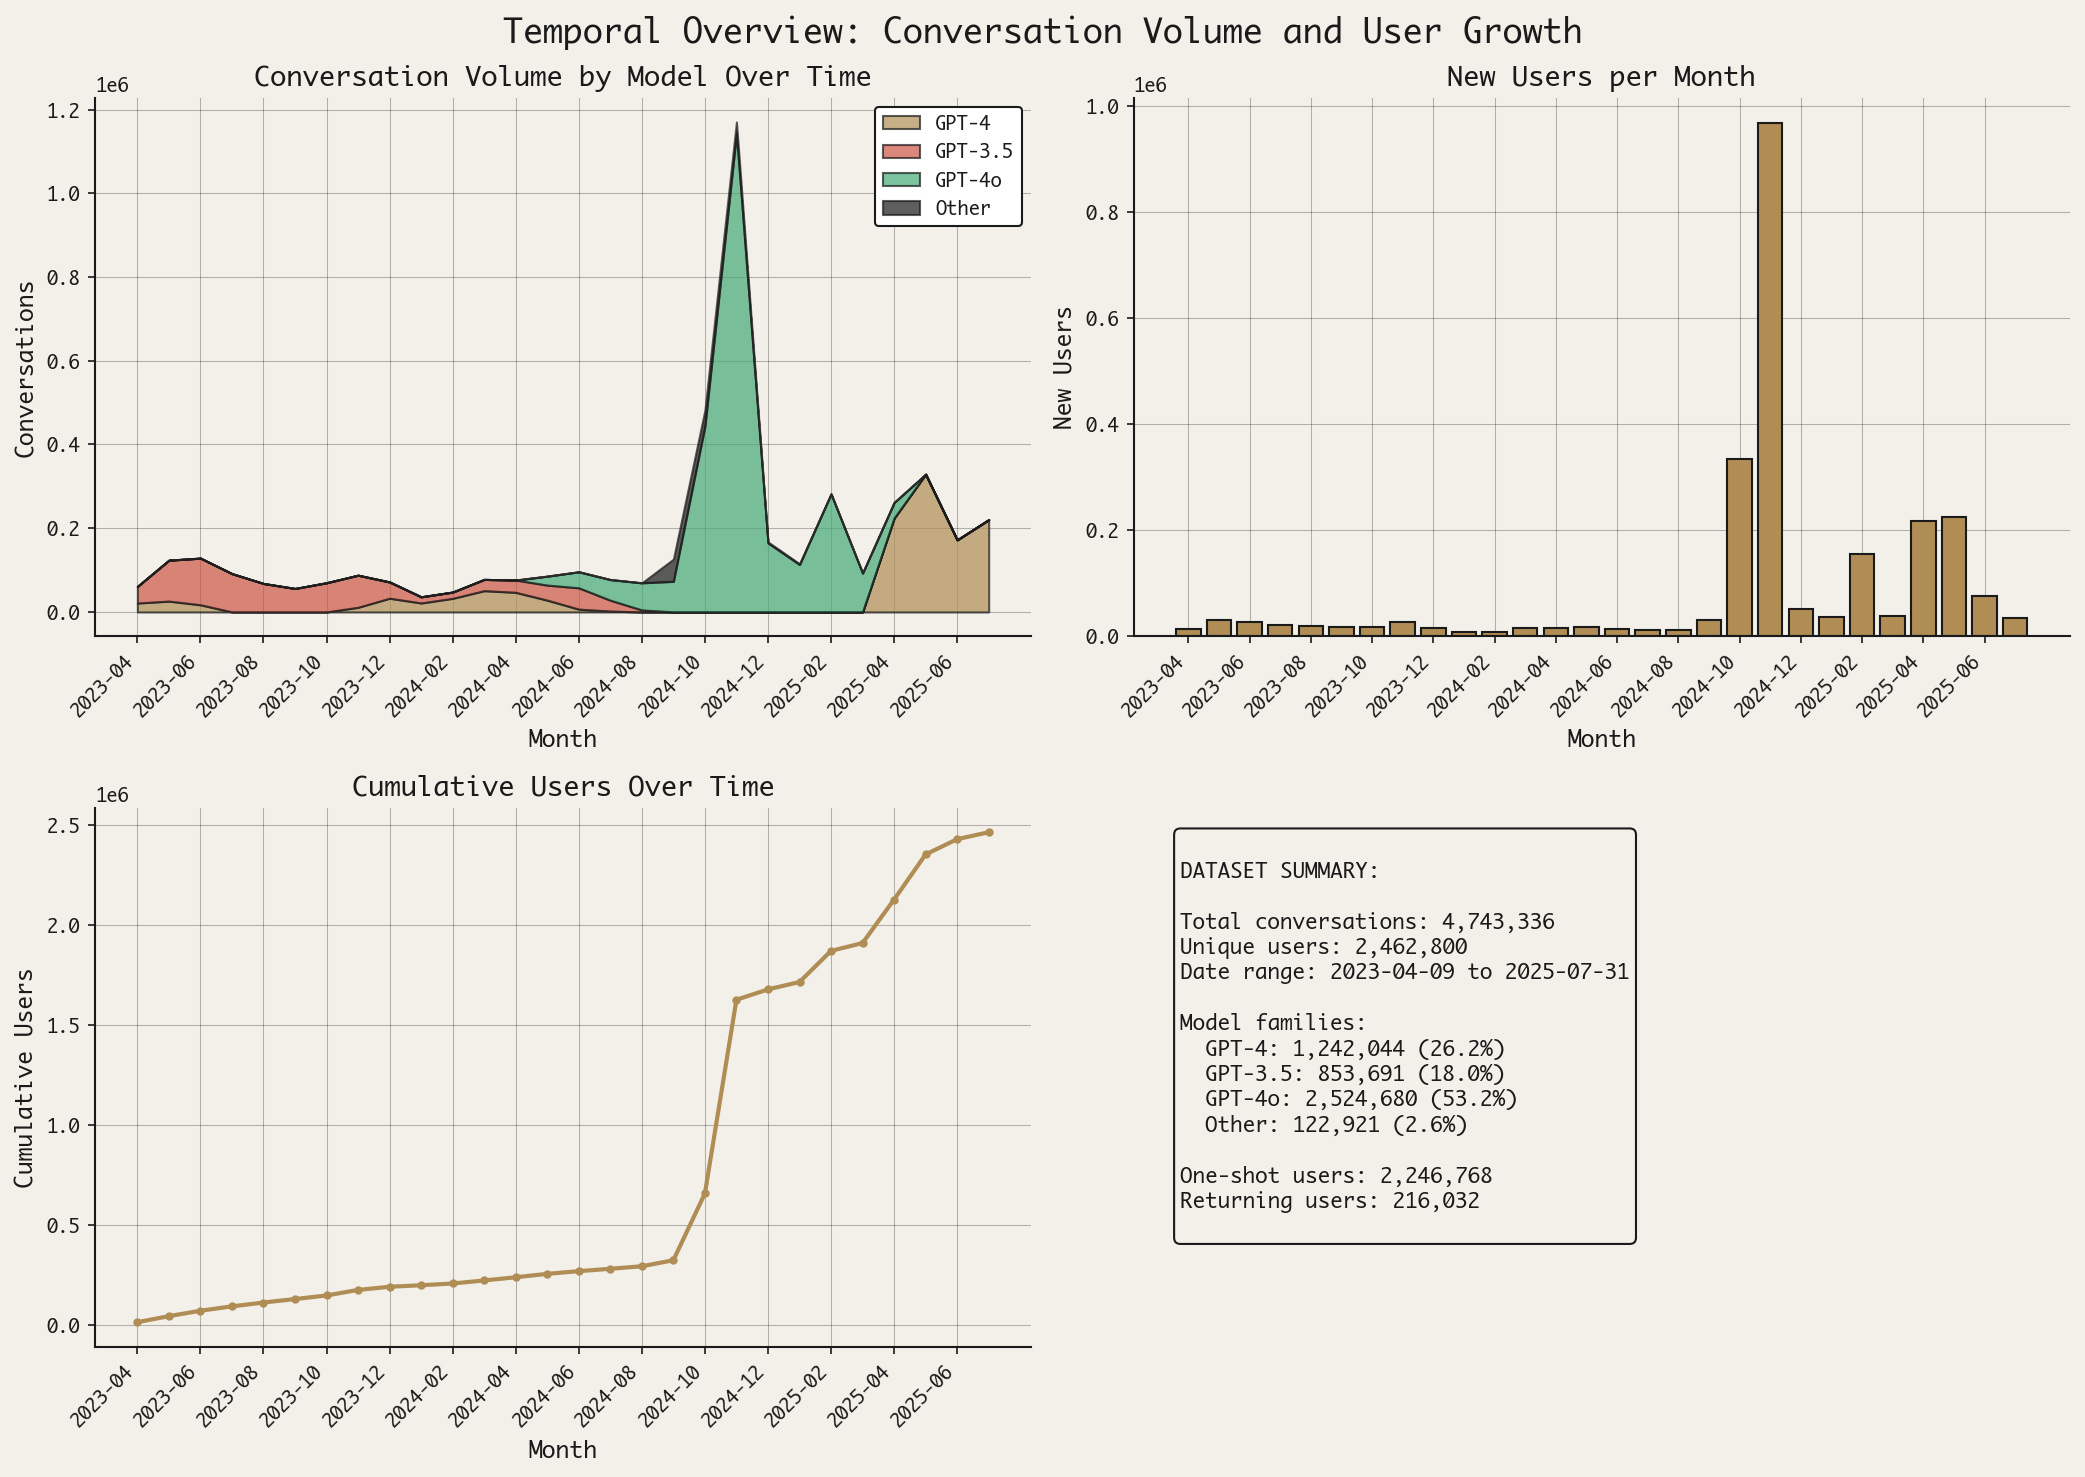


Temporal overview complete. Proceed to sample size calculator.


In [4]:
# ============================================================
# Data Loading and Temporal Overview
# ============================================================

# Data paths
PROTEST_USERS = '../outputs/data/protest_with_users/*.parquet'
RAW_DATA = '../data/wildchat-raw/data/*.parquet'

# Load preprocessed data with user IDs
print("Loading data...")
df_users = pl.scan_parquet(PROTEST_USERS).collect()
print(f"Loaded {len(df_users):,} conversations")
print(f"Unique users: {df_users['user_id'].n_unique():,}")

# Check if 'model' column exists
if 'model' not in df_users.columns and 'model_family' not in df_users.columns:
    print("Warning: 'model' column not found. Attempting to extract from raw data...")
    # This would require loading raw data - for now, we'll check if model_family exists
    if 'model_family' not in df_users.columns:
        print("  Creating model_family from available columns...")
        # If we have a model column elsewhere, extract it
        # For now, we'll assume it might be in the data
        pass

# Add temporal columns
df_users = df_users.with_columns([
    pl.col('timestamp').dt.truncate('1mo').alias('month'),
    pl.col('timestamp').dt.strftime('%Y-%m').alias('year_month'),
])

# Create model_family if not exists (check if 'model' column exists)
if 'model' in df_users.columns and 'model_family' not in df_users.columns:
    df_users = df_users.with_columns([
        pl.when(pl.col('model').str.contains('gpt-4o', literal=False))
          .then(pl.lit('GPT-4o'))
          .when(pl.col('model').str.contains('gpt-4', literal=False))
          .then(pl.lit('GPT-4'))
          .otherwise(pl.lit('GPT-3.5'))
          .alias('model_family')
    ])
elif 'model_family' not in df_users.columns:
    # If neither exists, create a placeholder
    print("Warning: No model information found. Creating placeholder.")
    df_users = df_users.with_columns([
        pl.lit('Unknown').alias('model_family')
    ])

# Compute user-level first conversation date (preliminary - will be expanded in Cell 4)
user_first_conv_prelim = df_users.group_by('user_id').agg([
    pl.col('timestamp').min().alias('first_conv_date'),
    pl.len().alias('n_conversations'),
])

print(f"\nUser statistics:")
print(f"  Users with 1 conversation: {(user_first_conv_prelim['n_conversations'] == 1).sum():,}")
print(f"  Users with 2+ conversations: {(user_first_conv_prelim['n_conversations'] >= 2).sum():,}")

# Visualize conversation volume over time by model
print("\nGenerating temporal visualizations...")

# Panel 1: Stacked area - conversations by model over time
monthly_by_model = df_users.group_by(['year_month', 'model_family']).agg(
    pl.len().alias('n_conversations')
).sort('year_month')

# Pivot for stacked area
monthly_pivot = monthly_by_model.pivot(
    index='year_month',
    columns='model_family',
    values='n_conversations',
    aggregate_function='sum'
).fill_null(0)

# Panel 2: New users per month
new_users_monthly = user_first_conv_prelim.with_columns(
    pl.col('first_conv_date').dt.strftime('%Y-%m').alias('first_month')
).group_by('first_month').agg(
    pl.len().alias('new_users')
).sort('first_month')

# Panel 3: Cumulative users
cumulative_users = new_users_monthly.with_columns(
    pl.col('new_users').cum_sum().alias('cumulative_users')
)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temporal Overview: Conversation Volume and User Growth', 
             fontsize=16, fontweight='bold', color=BRAND['ink'])

# Panel 1: Stacked area chart by model
ax = axes[0, 0]
months = monthly_pivot['year_month'].to_list()
model_families = [col for col in monthly_pivot.columns if col != 'year_month']
# Create color list that can handle any number of models
base_colors = [BRAND['gold'], BRAND['alert'], BRAND['success'], BRAND['ink'], FADED]
colors = [base_colors[i % len(base_colors)] for i in range(len(model_families))]

bottom = np.zeros(len(months))
for i, model in enumerate(model_families):
    values = monthly_pivot[model].to_numpy()
    ax.fill_between(range(len(months)), bottom, bottom + values, 
                    label=model, color=colors[i], alpha=0.7, edgecolor=BRAND['ink'])
    bottom += values

ax.set_xticks(range(0, len(months), max(1, len(months)//12)))
ax.set_xticklabels([months[i] for i in range(0, len(months), max(1, len(months)//12))], 
                    rotation=45, ha='right')
apply_phronos_style(ax, title='Conversation Volume by Model Over Time', 
                   xlabel='Month', ylabel='Conversations')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# Panel 2: New users per month
ax = axes[0, 1]
months_new = new_users_monthly['first_month'].to_list()
new_user_counts = new_users_monthly['new_users'].to_list()
ax.bar(range(len(months_new)), new_user_counts, color=BRAND['gold'], edgecolor=BRAND['ink'])
ax.set_xticks(range(0, len(months_new), max(1, len(months_new)//12)))
ax.set_xticklabels([months_new[i] for i in range(0, len(months_new), max(1, len(months_new)//12))], 
                   rotation=45, ha='right')
apply_phronos_style(ax, title='New Users per Month', xlabel='Month', ylabel='New Users')

# Panel 3: Cumulative users
ax = axes[1, 0]
ax.plot(range(len(cumulative_users)), cumulative_users['cumulative_users'].to_numpy(), 
        color=BRAND['gold'], linewidth=2, marker='o', markersize=3)
ax.set_xticks(range(0, len(months_new), max(1, len(months_new)//12)))
ax.set_xticklabels([months_new[i] for i in range(0, len(months_new), max(1, len(months_new)//12))], 
                   rotation=45, ha='right')
apply_phronos_style(ax, title='Cumulative Users Over Time', xlabel='Month', ylabel='Cumulative Users')

# Panel 4: Data range summary
ax = axes[1, 1]
ax.axis('off')
data_start = df_users['timestamp'].min()
data_end = df_users['timestamp'].max()
summary_text = f"""
DATASET SUMMARY:

Total conversations: {len(df_users):,}
Unique users: {df_users['user_id'].n_unique():,}
Date range: {data_start.strftime('%Y-%m-%d')} to {data_end.strftime('%Y-%m-%d')}

Model families:
"""
for model in model_families:
    count = (df_users['model_family'] == model).sum()
    pct = 100 * count / len(df_users)
    summary_text += f"  {model}: {count:,} ({pct:.1f}%)\n"

summary_text += f"""
One-shot users: {(user_first_conv_prelim['n_conversations'] == 1).sum():,}
Returning users: {(user_first_conv_prelim['n_conversations'] >= 2).sum():,}
"""
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor=BRAND['paper'], edgecolor=BRAND['ink']))

plt.tight_layout()
save_figure(fig, 'temporal_overview')
plt.show()

print("\n" + "="*70)
print("Temporal overview complete. Proceed to sample size calculator.")
print("="*70)


SAMPLE SIZE CALCULATOR: Test Period Options

For each candidate cutoff date:
  - New users = users whose first conversation is >= cutoff
  - With follow-up = new users with at least 60 days before data end
  - Return rate = estimated % who have 2+ conversations

Cutoff Date     New Users    With Follow-up  Return Rate  N Returners 
----------------------------------------------------------------------
2024-10-01        2,138,319      2,027,444        3.6%      72,889
2024-12-01          836,813        725,938        4.3%      31,267
2025-01-01          785,065        674,190        3.8%      25,353
2025-02-01          748,251        637,376        3.4%      21,958
2025-03-01          592,676        481,801        3.1%      14,766
Saved: ../outputs/figures/pub_sample_size_calculator.png


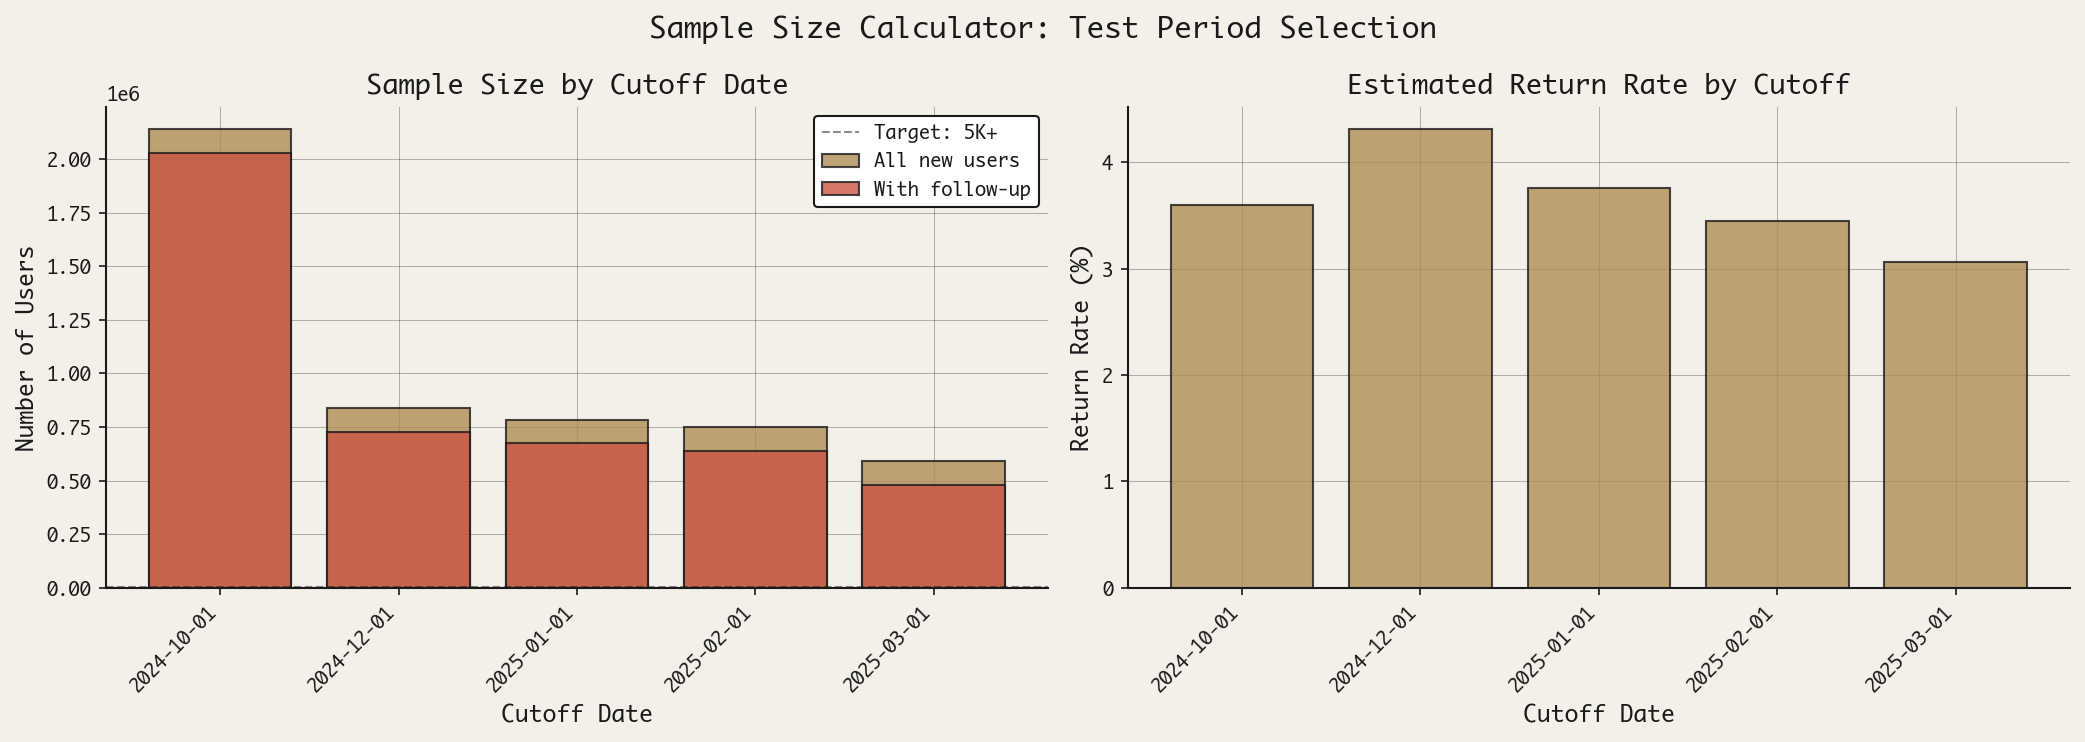


USER DECISION POINT: Select Train/Test Cutoff

Recommended: Choose cutoff that provides:
  - At least 5,000 new users with follow-up (for stable AUC estimates)
  - Sufficient return rate for class balance
  - Clear temporal separation from training period

Default selection: 2025-01-01 00:00:00.alias("datetime").strict_cast(Date).alias("date")
Follow-up window: 60 days

To change, modify TRAIN_TEST_CUTOFF in this cell.


In [5]:
# ============================================================
# Sample Size Calculator for Test Period
# ============================================================

def compute_test_sample_sizes(df_users: pl.DataFrame, user_first_conv: pl.DataFrame, 
                               cutoff_dates: list, followup_days: int = 60) -> pl.DataFrame:
    """
    For each candidate cutoff date, compute:
    - N new users in test period
    - N new users with 60+ days follow-up (for outcome measurement)
    - Return rate in test period (for class balance)
    """
    results = []
    data_end = df_users['timestamp'].max()
    
    for cutoff in cutoff_dates:
        # New users = first conversation >= cutoff
        new_users = user_first_conv.filter(
            pl.col('first_conv_date') >= cutoff
        )
        
        # Users with sufficient follow-up (at least followup_days before data end)
        users_with_followup = new_users.filter(
            pl.col('first_conv_date') <= (data_end - pl.duration(days=followup_days))
        )
        
        # Return rate among these users (using n_conversations >= 2 as proxy)
        # Note: This is a preliminary estimate - actual outcome will use days_to_return
        if len(users_with_followup) > 0:
            return_rate = users_with_followup.filter(pl.col('n_conversations') >= 2).height / len(users_with_followup)
        else:
            return_rate = 0.0
        
        results.append({
            'cutoff': cutoff,
            'n_new_users': len(new_users),
            'n_with_followup': len(users_with_followup),
            'return_rate': return_rate,
            'n_returners': int(len(users_with_followup) * return_rate) if len(users_with_followup) > 0 else 0
        })
    
    return pl.DataFrame(results)

# Candidate cutoff dates
cutoff_dates = [
    pl.date(2024, 10, 1),
    pl.date(2024, 12, 1),
    pl.date(2025, 1, 1),
    pl.date(2025, 2, 1),
    pl.date(2025, 3, 1),
]

FOLLOWUP_DAYS = 60  # Days required for outcome measurement

sample_size_table = compute_test_sample_sizes(df_users, user_first_conv_prelim, cutoff_dates, FOLLOWUP_DAYS)

print("="*70)
print("SAMPLE SIZE CALCULATOR: Test Period Options")
print("="*70)
print("\nFor each candidate cutoff date:")
print(f"  - New users = users whose first conversation is >= cutoff")
print(f"  - With follow-up = new users with at least {FOLLOWUP_DAYS} days before data end")
print(f"  - Return rate = estimated % who have 2+ conversations")
print()

# Display table
print(f"{'Cutoff Date':<15} {'New Users':<12} {'With Follow-up':<15} {'Return Rate':<12} {'N Returners':<12}")
print("-"*70)
for row in sample_size_table.iter_rows(named=True):
    cutoff_str = str(row['cutoff'])[:10]
    print(f"{cutoff_str:<15} {row['n_new_users']:>11,} {row['n_with_followup']:>14,} {row['return_rate']:>11.1%} {row['n_returners']:>11,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sample Size Calculator: Test Period Selection', 
             fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: New users vs cutoff
ax = axes[0]
cutoff_strs = [str(c)[:10] for c in cutoff_dates]
ax.bar(range(len(cutoff_dates)), sample_size_table['n_new_users'].to_numpy(), 
       color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8, label='All new users')
ax.bar(range(len(cutoff_dates)), sample_size_table['n_with_followup'].to_numpy(), 
       color=BRAND['alert'], edgecolor=BRAND['ink'], alpha=0.8, label='With follow-up')
ax.set_xticks(range(len(cutoff_dates)))
ax.set_xticklabels(cutoff_strs, rotation=45, ha='right')
apply_phronos_style(ax, title='Sample Size by Cutoff Date', xlabel='Cutoff Date', ylabel='Number of Users')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
ax.axhline(5000, color=BRAND['ink'], linestyle='--', linewidth=1, alpha=0.5, label='Target: 5K+')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# Panel 2: Return rate by cutoff
ax = axes[1]
ax.bar(range(len(cutoff_dates)), [r * 100 for r in sample_size_table['return_rate'].to_numpy()], 
       color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.set_xticks(range(len(cutoff_dates)))
ax.set_xticklabels(cutoff_strs, rotation=45, ha='right')
apply_phronos_style(ax, title='Estimated Return Rate by Cutoff', xlabel='Cutoff Date', ylabel='Return Rate (%)')

plt.tight_layout()
save_figure(fig, 'sample_size_calculator')
plt.show()

# USER DECISION POINT
print("\n" + "="*70)
print("USER DECISION POINT: Select Train/Test Cutoff")
print("="*70)
print("\nRecommended: Choose cutoff that provides:")
print("  - At least 5,000 new users with follow-up (for stable AUC estimates)")
print("  - Sufficient return rate for class balance")
print("  - Clear temporal separation from training period")
print()

# Default selection
TRAIN_TEST_CUTOFF = pl.date(2025, 1, 1)  # Default: January 1, 2025
print(f"Default selection: {TRAIN_TEST_CUTOFF}")
print(f"Follow-up window: {FOLLOWUP_DAYS} days")
print("\nTo change, modify TRAIN_TEST_CUTOFF in this cell.")
print("="*70)


## ⚠️ TEST DATA LOCK

From this point forward, DO NOT run any descriptive statistics, visualizations, 
or exploratory analysis on data from users whose first conversation is >= cutoff.

The test set will be evaluated EXACTLY ONCE in Cell 13.
Any peeking contaminates the confirmatory analysis.


In [6]:
# ============================================================
# Define Train/Test Splits with New-User Restriction
# ============================================================

# CRITICAL: Test set contains ONLY users whose first-ever conversation is >= cutoff

# Compute user_first_conv with CORRECTED aggregation to get second conversation date
print("Computing user-level statistics with second conversation date...")
user_first_conv = df_users.group_by('user_id').agg([
    pl.col('timestamp').min().alias('first_conv_date'),
    pl.col('timestamp').sort().get(1).alias('second_conv_date'),  # 2nd conversation (None if only 1)
    pl.col('timestamp').max().alias('last_conv_date'),
    pl.len().alias('n_conversations'),
])

print(f"Computed statistics for {len(user_first_conv):,} users")
print(f"  Users with 1 conversation: {(user_first_conv['second_conv_date'].is_null()).sum():,}")
print(f"  Users with 2+ conversations: {(user_first_conv['second_conv_date'].is_not_null()).sum():,}")

# Identify new users in test period
data_end = df_users['timestamp'].max()

test_user_ids = set(
    user_first_conv.filter(
        (pl.col('first_conv_date') >= TRAIN_TEST_CUTOFF) &
        (pl.col('first_conv_date') <= (data_end - pl.duration(days=FOLLOWUP_DAYS)))
    )['user_id'].to_list()
)

train_user_ids = set(
    user_first_conv.filter(
        pl.col('first_conv_date') < TRAIN_TEST_CUTOFF
    )['user_id'].to_list()
)

print("\n" + "="*70)
print("TRAIN/TEST SPLIT")
print("="*70)
print(f"Training users: {len(train_user_ids):,}")
print(f"Test users (new only): {len(test_user_ids):,}")
print(f"Overlap check: {len(train_user_ids & test_user_ids)} (should be 0)")

# Verify no contamination
assert len(train_user_ids & test_user_ids) == 0, "Train/test contamination detected!"

print("\n✓ Train/test split verified: No overlap")
print(f"  Training period: < {TRAIN_TEST_CUTOFF}")
print(f"  Test period: >= {TRAIN_TEST_CUTOFF} (new users only)")
print("="*70)


Computing user-level statistics with second conversation date...
Computed statistics for 2,462,800 users
  Users with 1 conversation: 2,246,768
  Users with 2+ conversations: 216,032

TRAIN/TEST SPLIT
Training users: 1,677,735
Test users (new only): 674,190
Overlap check: 0 (should be 0)

✓ Train/test split verified: No overlap
  Training period: < 2025-01-01 00:00:00.alias("datetime").strict_cast(Date).alias("date")
  Test period: >= 2025-01-01 00:00:00.alias("datetime").strict_cast(Date).alias("date") (new users only)


In [7]:
# ============================================================
# Define Outcome Variable with Fixed Time Window
# ============================================================

def compute_return_outcome(user_first_conv: pl.DataFrame, window_days: int = 60) -> pl.DataFrame:
    """
    Return = user had 2+ conversations within window_days of first conversation.
    
    CORRECTED: Uses days_to_return (second_conv_date - first_conv_date), 
    NOT active_span_days (last_conv_date - first_conv_date).
    
    This standardizes the outcome across users with different observation periods.
    """
    return user_first_conv.with_columns([
        # Days between first and second conversation (CORRECTED)
        ((pl.col('second_conv_date') - pl.col('first_conv_date')).dt.total_days()).alias('days_to_return'),
        
        # Binary outcome: returned within window
        (
            (pl.col('n_conversations') >= 2) & 
            (pl.col('second_conv_date').is_not_null()) &
            ((pl.col('second_conv_date') - pl.col('first_conv_date')).dt.total_days() <= window_days)
        ).alias(f'returned_{window_days}d'),
        
        # Also keep raw "ever returned" for comparison
        (pl.col('n_conversations') >= 2).alias('returned_ever')
    ])

user_outcomes = compute_return_outcome(user_first_conv, FOLLOWUP_DAYS)

# Check outcome rates
print("="*70)
print("OUTCOME VARIABLE: Return Behavior")
print("="*70)
print(f"\nOutcome definition: returned_{FOLLOWUP_DAYS}d")
print(f"  = (n_conversations >= 2) AND (days_to_return <= {FOLLOWUP_DAYS})")
print(f"  where days_to_return = second_conv_date - first_conv_date")
print()

for split_name, user_ids in [('Train', train_user_ids), ('Test', test_user_ids)]:
    split_data = user_outcomes.filter(pl.col('user_id').is_in(user_ids))
    rate_60d = split_data[f'returned_{FOLLOWUP_DAYS}d'].mean()
    rate_ever = split_data['returned_ever'].mean()
    n_users = len(split_data)
    print(f"{split_name}:")
    print(f"  Users: {n_users:,}")
    print(f"  Returned within {FOLLOWUP_DAYS}d: {100*rate_60d:.1f}% ({int(n_users * rate_60d):,} users)")
    print(f"  Returned ever: {100*rate_ever:.1f}% ({int(n_users * rate_ever):,} users)")
    print()

# Show distribution of days_to_return for users who returned
returned_users = user_outcomes.filter(pl.col(f'returned_{FOLLOWUP_DAYS}d') == True)
if len(returned_users) > 0:
    days_to_return = returned_users['days_to_return'].to_numpy()
    print(f"Days to return (for users who returned within {FOLLOWUP_DAYS}d):")
    print(f"  Mean: {np.mean(days_to_return):.1f} days")
    print(f"  Median: {np.median(days_to_return):.1f} days")
    print(f"  Min: {np.min(days_to_return):.0f} days")
    print(f"  Max: {np.max(days_to_return):.0f} days")
    print(f"  P75: {np.percentile(days_to_return, 75):.1f} days")
    print(f"  P90: {np.percentile(days_to_return, 90):.1f} days")

print("="*70)


OUTCOME VARIABLE: Return Behavior

Outcome definition: returned_60d
  = (n_conversations >= 2) AND (days_to_return <= 60)
  where days_to_return = second_conv_date - first_conv_date

Train:
  Users: 1,677,735
  Returned within 60d: 11.2% (187,131 users)
  Returned ever: 11.2% (187,851 users)

Test:
  Users: 674,190
  Returned within 60d: 3.8% (25,298 users)
  Returned ever: 3.8% (25,353 users)

Days to return (for users who returned within 60d):
  Mean: 0.9 days
  Median: 0.0 days
  Min: 0 days
  Max: 60 days
  P75: 0.0 days
  P90: 1.0 days


In [8]:
# ============================================================
# Extract First-Prompt Features
# ============================================================

import glob
import gc
import json

def extract_first_turn(conversation):
    """Extract the first user message from a conversation."""
    if conversation is None:
        return ""
    for msg in conversation:
        if msg.get('role') == 'user':
            content = msg.get('content', '')
            return (content[:2000] if content else "") or ""  # Limit length for memory
    return ""

def extract_first_turn_features(conversation):
    """Extract features from first user message."""
    first_user_msg = extract_first_turn(conversation)
    
    if not first_user_msg:
        return {
            'word_count': 0,
            'char_count': 0,
            'first_person_singular_rate': 0.0,
            'first_person_plural_rate': 0.0,
            'second_person_rate': 0.0,
            'politeness_rate': 0.0,
            'has_question': 0,
            'is_imperative': 0,
            'avg_word_length': 0.0,
            'is_greeting': 0,
        }
    
    text = first_user_msg
    text_lower = text.lower()
    words = text.split()
    n_words = len(words)
    
    if n_words == 0:
        return {
            'word_count': 0,
            'char_count': len(text),
            'first_person_singular_rate': 0.0,
            'first_person_plural_rate': 0.0,
            'second_person_rate': 0.0,
            'politeness_rate': 0.0,
            'has_question': 0,
            'is_imperative': 0,
            'avg_word_length': 0.0,
            'is_greeting': 0,
        }
    
    # Pronoun counts (per 100 words for rate)
    first_person_singular = sum(1 for w in words if w.lower() in {'i', 'me', 'my', 'mine', 'myself'})
    first_person_plural = sum(1 for w in words if w.lower() in {'we', 'us', 'our', 'ours', 'ourselves'})
    second_person = sum(1 for w in words if w.lower() in {'you', 'your', 'yours', 'yourself', 'yourselves', 'u'})
    
    # Politeness markers
    politeness_words = {'please', 'thank', 'thanks', 'appreciate', 'kindly', 'would you', 'could you'}
    politeness_count = sum(1 for w in words if w.lower() in politeness_words)
    
    # Question detection
    has_question = '?' in text or text_lower.startswith(('what', 'how', 'why', 'when', 'where', 'who', 'can', 'could', 'would', 'is', 'are', 'do', 'does'))
    
    # Imperative detection (starts with verb)
    imperative_starters = {'write', 'create', 'make', 'generate', 'list', 'explain', 'tell', 'show', 'find', 'help', 'give'}
    first_word = words[0].lower().rstrip(',:') if words else ''
    is_imperative = first_word in imperative_starters
    
    # Word complexity (average word length)
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    
    # Greeting detection
    greeting_patterns = ['hi', 'hello', 'hey', 'good morning', 'good afternoon', 'good evening', 'greetings']
    is_greeting = any(text_lower.startswith(g) for g in greeting_patterns)
    
    return {
        'word_count': n_words,
        'char_count': len(text),
        'first_person_singular_rate': 100 * first_person_singular / n_words,
        'first_person_plural_rate': 100 * first_person_plural / n_words,
        'second_person_rate': 100 * second_person / n_words,
        'politeness_rate': 100 * politeness_count / n_words,
        'has_question': int(has_question),
        'is_imperative': int(is_imperative),
        'avg_word_length': avg_word_length,
        'is_greeting': int(is_greeting),
    }

# Get first conversation hash for each user (for training and test separately)
print("Identifying first conversations for feature extraction...")

# For training: get first conversation hash for each training user
train_first_convs = df_users.filter(
    pl.col('user_id').is_in(train_user_ids)
).sort('timestamp').group_by('user_id').first().select(['user_id', 'conversation_hash'])

# For test: get first conversation hash for each test user  
test_first_convs = df_users.filter(
    pl.col('user_id').is_in(test_user_ids)
).sort('timestamp').group_by('user_id').first().select(['user_id', 'conversation_hash'])

train_hashes = set(train_first_convs['conversation_hash'].to_list())
test_hashes = set(test_first_convs['conversation_hash'].to_list())

print(f"Training first conversations: {len(train_hashes):,}")
print(f"Test first conversations: {len(test_hashes):,}")

# Load raw conversations for first conversations only
print("\nLoading raw conversations for first conversations...")
print("(Processing by parquet file to avoid scanning all files multiple times)")

# #region agent log
import json
import psutil
import glob
def debug_log(loc, msg, data=None):
    try:
        mem_mb = psutil.Process().memory_info().rss / 1024 / 1024
        data = data or {}
        data['mem_mb'] = round(mem_mb, 1)
    except: pass
    with open('/Users/vishal/Documents/GitHub/phronos-research/.cursor/debug.log', 'a') as f:
        f.write(json.dumps({'location': loc, 'message': msg, 'data': data, 'timestamp': __import__('time').time(), 'sessionId': 'debug-session', 'runId': 'run2', 'hypothesisId': 'B'}) + '\n')
# #endregion

# Get all conversation hashes we need
all_hashes = train_hashes | test_hashes
print(f"Total unique first conversations to load: {len(all_hashes):,}")

# #region agent log
debug_log('cell7:before_file_processing', 'Before file processing', {'n_hashes': len(all_hashes), 'mem_mb': psutil.Process().memory_info().rss / 1024 / 1024})
# #endregion

# Process by parquet file instead of by hash batch
# This way we only scan each file once, not 47 times
parquet_files = sorted(glob.glob(RAW_DATA))
print(f"Processing {len(parquet_files)} parquet files...")

all_features = []
hashes_found = set()

for file_idx, parquet_file in enumerate(parquet_files):
    # #region agent log
    debug_log('cell7:file_start', f'File {file_idx+1}/{len(parquet_files)}', {'file_idx': file_idx, 'filename': parquet_file.split('/')[-1], 'mem_mb': psutil.Process().memory_info().rss / 1024 / 1024})
    # #endregion
    
    print(f"  File {file_idx+1}/{len(parquet_files)}: {parquet_file.split('/')[-1]}...")
    
    # Load file and filter to our hashes
    file_data = pl.read_parquet(
        parquet_file,
        columns=['conversation_hash', 'conversation']
    )
    
    # Filter to conversations we need
    file_filtered = file_data.filter(
        pl.col('conversation_hash').is_in(list(all_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    # #region agent log
    debug_log('cell7:file_loaded', f'File {file_idx+1} loaded', {'n_in_file': len(file_filtered), 'mem_mb': psutil.Process().memory_info().rss / 1024 / 1024})
    # #endregion
    
    # Extract features from this file's conversations
    file_features = []
    for row in file_filtered.iter_rows(named=True):
        features = extract_first_turn_features(row['conversation'])
        features['conversation_hash'] = row['conversation_hash']
        file_features.append(features)
        hashes_found.add(row['conversation_hash'])
    
    all_features.extend(file_features)
    
    # #region agent log
    debug_log('cell7:file_processed', f'File {file_idx+1} processed', {'n_features': len(file_features), 'total_features': len(all_features), 'hashes_found': len(hashes_found), 'mem_mb': psutil.Process().memory_info().rss / 1024 / 1024})
    # #endregion
    
    # Print progress before cleanup
    print(f"    Found {len(file_features):,} conversations, total so far: {len(all_features):,}")
    
    # Clean up
    del file_data, file_filtered, file_features
    gc.collect()

# #region agent log
debug_log('cell7:all_files_done', 'All files processed', {'total_features': len(all_features), 'hashes_found': len(hashes_found), 'hashes_expected': len(all_hashes), 'mem_mb': psutil.Process().memory_info().rss / 1024 / 1024})
# #endregion

features_df = pl.DataFrame(all_features)
del all_features
gc.collect()

print(f"\nExtracted features for {len(features_df):,} conversations")
print(f"  Expected: {len(all_hashes):,}, Found: {len(hashes_found):,}")
if len(hashes_found) < len(all_hashes):
    missing = len(all_hashes) - len(hashes_found)
    print(f"  Warning: {missing:,} conversations not found in raw data")

# Join with user outcomes
print("Joining features with user outcomes...")
# Get user_id from first conversations
first_convs_with_user = df_users.filter(
    pl.col('conversation_hash').is_in(features_df['conversation_hash'].to_list())
).select(['conversation_hash', 'user_id']).unique(subset=['conversation_hash'])

features_with_user = features_df.join(
    first_convs_with_user,
    on='conversation_hash',
    how='left'
)

# Join with outcomes
first_turn_features = features_with_user.join(
    user_outcomes.select(['user_id', f'returned_{FOLLOWUP_DAYS}d', 'returned_ever']),
    on='user_id',
    how='left'
)

print(f"\nFinal feature dataset: {len(first_turn_features):,} conversations")
print(f"  Training: {first_turn_features.filter(pl.col('user_id').is_in(train_user_ids)).height:,}")
print(f"  Test: {first_turn_features.filter(pl.col('user_id').is_in(test_user_ids)).height:,}")

# Show feature summary
print("\nFeature summary (training data only):")
train_features = first_turn_features.filter(pl.col('user_id').is_in(train_user_ids))
print(f"  Avg word count: {train_features['word_count'].mean():.1f}")
print(f"  Avg first-person singular rate: {train_features['first_person_singular_rate'].mean():.2f}")
print(f"  Avg second-person rate: {train_features['second_person_rate'].mean():.2f}")
print(f"  Has question: {100 * train_features['has_question'].mean():.1f}%")
print(f"  Is imperative: {100 * train_features['is_imperative'].mean():.1f}%")
print(f"  Is greeting: {100 * train_features['is_greeting'].mean():.1f}%")

print("\n" + "="*70)
print("Feature extraction complete.")
print("="*70)


Identifying first conversations for feature extraction...
Training first conversations: 1,670,368
Test first conversations: 665,540

Loading raw conversations for first conversations...
(Processing by parquet file to avoid scanning all files multiple times)
Total unique first conversations to load: 2,335,464
Processing 127 parquet files...
  File 1/127: train-00000-of-00127.parquet...
    Found 9,727 conversations, total so far: 9,727
  File 2/127: train-00001-of-00127.parquet...
    Found 8,684 conversations, total so far: 18,411
  File 3/127: train-00002-of-00127.parquet...
    Found 10,028 conversations, total so far: 28,439
  File 4/127: train-00003-of-00127.parquet...
    Found 8,940 conversations, total so far: 37,379
  File 5/127: train-00004-of-00127.parquet...
    Found 9,414 conversations, total so far: 46,793
  File 6/127: train-00005-of-00127.parquet...
    Found 8,646 conversations, total so far: 55,439
  File 7/127: train-00006-of-00127.parquet...
    Found 8,354 conversa

In [9]:
# ============================================================
# Intent Classification
# ============================================================

def classify_intent(text):
    """
    Classify first-turn intent using keyword patterns.
    Expanded to reduce 'other' category. For production, use LLM-based classification.
    """
    text_lower = str(text).lower()
    
    # Intent patterns (order matters - first match wins, more specific first)
    patterns = [
        # Conversational/Social
        ('greeting', [r'^hi\b', r'^hello', r'^hey\b', r'^good morning', r'^good evening', r"^what's up"]),
        ('roleplay', [r'act as', r'you are a', r'pretend', r'roleplay', r'scenario', r'imagine you', r'play the role']),
        ('emotional_support', [r'i feel', r"i'm feeling", r'anxious', r'depressed', r'lonely', r'stressed', 
                               r'advice', r'help me cope', r'i am sad', r'i am worried', r'relationship']),
        ('chat', [r'how are you', r'tell me about yourself', r"what's your name", r'are you ai', r'who made you']),
        
        # Creative
        ('creative_writing', [r'write a story', r'write a poem', r'creative', r'fiction', r'write me a', 
                              r'compose', r'short story', r'lyrics', r'screenplay', r'novel']),
        ('humor', [r'joke', r'funny', r'make me laugh', r'pun', r'riddle']),
        
        # Technical
        ('coding', [r'code', r'python', r'javascript', r'java\b', r'function', r'error', r'debug', 
                   r'programming', r'script', r'algorithm', r'api', r'sql', r'html', r'css', r'react',
                   r'bug', r'compile', r'syntax', r'variable', r'array', r'loop']),
        ('math', [r'calculate', r'solve', r'equation', r'math', r'\d+\s*[\+\-\*\/\^]\s*\d+', r'derivative',
                 r'integral', r'probability', r'statistics', r'percentage']),
        
        # Information
        ('explain', [r'explain', r'how does', r'what is', r'why does', r'help me understand', r'tell me about',
                    r'what are', r'describe', r'define', r'meaning of']),
        ('factual', [r'who is', r'when did', r'where is', r'what year', r'how many', r'how much', r'how old',
                    r'capital of', r'population', r'distance', r'history of']),
        ('how_to', [r'how to', r'how do i', r'how can i', r'steps to', r'tutorial', r'guide', r'instructions']),
        
        # Tasks
        ('summarize', [r'summarize', r'tldr', r'summary', r'key points', r'main ideas', r'brief']),
        ('translate', [r'translate', r'in spanish', r'in french', r'to english', r'in german', r'in chinese',
                      r'in japanese', r'in korean', r'in portuguese', r'in italian', r'in russian']),
        ('rewrite', [r'rewrite', r'paraphrase', r'rephrase', r'improve', r'make it better', r'fix my',
                    r'correct', r'proofread', r'edit this', r'grammar']),
        ('brainstorm', [r'ideas for', r'brainstorm', r'suggestions', r'what are some', r'list of', r'give me',
                       r'recommend', r'options', r'alternatives']),
        ('task_completion', [r'write an email', r'draft', r'create a', r'make a', r'generate', r'write a letter',
                            r'write a resume', r'cover letter', r'essay', r'report', r'presentation']),
        
        # Analysis
        ('compare', [r'compare', r'difference between', r'versus', r' vs ', r'better than', r'pros and cons']),
        ('opinion', [r'what do you think', r'your opinion', r'should i', r'is it worth', r'recommend']),
        
        # Commands (short/direct)
        ('command', [r'^list\b', r'^name\b', r'^show\b', r'^find\b', r'^search\b', r'^get\b']),
        
        # Content (text provided)
        ('analyze_text', [r'analyze', r'review', r'feedback', r'critique', r'evaluate']),
        ('continue', [r'continue', r'finish', r'complete this', r'what happens next']),
    ]
    
    for intent, keywords in patterns:
        for kw in keywords:
            if re.search(kw, text_lower):
                return intent
    
    # Check text length for remaining - very short prompts are often simple queries
    if len(text_lower) < 20:
        return 'short_query'
    
    return 'other'

# Extract first_turn text from raw conversations for intent classification
print("Extracting first-turn text for intent classification...")
print("Processing by parquet file to avoid...") 
# Get conversation hashes from feature dataset
feature_hashes = set(first_turn_features['conversation_hash'].to_list())
print(f"Extracting text for {len(feature_hashes):,} conversations")

# Process by parquet file (same approach as feature extraction)
parquet_files = sorted(glob.glob(RAW_DATA))
print(f"Processing {len(parquet_files)} parquet files for intent classification...")

first_turn_texts = {}
hashes_found_intent = set()

for file_idx, parquet_file in enumerate(parquet_files):
    # Load file and filter to our hashes
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(feature_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    # Extract first turn text from this file's conversations
    for row in file_filtered.iter_rows(named=True):
        first_turn = extract_first_turn(row['conversation'])
        first_turn_texts[row['conversation_hash']] = first_turn
        hashes_found_intent.add(row['conversation_hash'])
    
    # Clean up
    del file_data, file_filtered
    gc.collect()
    
    if (file_idx + 1) % 10 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files, found {len(first_turn_texts):,} conversations...")

print(f"\nExtracted first-turn text for {len(first_turn_texts):,} conversations")
if len(hashes_found_intent) < len(feature_hashes):
    missing = len(feature_hashes) - len(hashes_found_intent)
    print(f"  Warning: {missing:,} conversations not found in raw data")

# Add to feature dataset
first_turn_text_df = pl.DataFrame({
    'conversation_hash': list(first_turn_texts.keys()),
    'first_turn': list(first_turn_texts.values())
})

first_turn_features = first_turn_features.join(
    first_turn_text_df,
    on='conversation_hash',
    how='left'
)

del first_turn_texts, first_turn_text_df
gc.collect()

# Apply intent classification
print("Classifying intents...")
first_turn_features = first_turn_features.with_columns([
    pl.col('first_turn').map_elements(classify_intent, return_dtype=pl.Utf8).alias('intent')
])

# Create dummy variables for key intents (for confounder control)
print("Creating intent dummy variables...")
key_intents = ['coding', 'roleplay', 'creative_writing', 'emotional_support']

for intent in key_intents:
    first_turn_features = first_turn_features.with_columns([
        (pl.col('intent') == intent).cast(pl.Int8).alias(f'intent_{intent}')
    ])

# Show intent distribution (training data only)
print("\nIntent distribution (training data only):")
train_intents = first_turn_features.filter(pl.col('user_id').is_in(train_user_ids))
intent_dist = train_intents['intent'].value_counts().sort('count', descending=True).head(10)
for row in intent_dist.iter_rows(named=True):
    pct = 100 * row['count'] / len(train_intents)
    print(f"  {row['intent']:<20}: {row['count']:>6,} ({pct:>5.1f}%)")

print("\n" + "="*70)
print("Intent classification complete.")
print("Note: Intent used for confounder control, not as primary predictor.")
print("="*70)


Extracting first-turn text for intent classification...
Processing by parquet file to avoid...
Extracting text for 2,335,464 conversations
Processing 127 parquet files for intent classification...
  Processed 10/127 files, found 85,375 conversations...
  Processed 20/127 files, found 189,064 conversations...
  Processed 30/127 files, found 260,311 conversations...
  Processed 40/127 files, found 340,093 conversations...
  Processed 50/127 files, found 610,566 conversations...
  Processed 60/127 files, found 855,988 conversations...
  Processed 70/127 files, found 1,195,646 conversations...
  Processed 80/127 files, found 1,545,269 conversations...
  Processed 90/127 files, found 1,694,089 conversations...
  Processed 100/127 files, found 1,886,274 conversations...
  Processed 110/127 files, found 2,152,093 conversations...
  Processed 120/127 files, found 2,335,464 conversations...

Extracted first-turn text for 2,335,464 conversations
Classifying intents...
Creating intent dummy varia

In [15]:
# ============================================================
# Build Feature Matrix and Helper Functions
# ============================================================

def build_feature_matrix(df: pl.DataFrame, feature_cols: list, outcome_col: str):
    """
    Build X, y matrices for modeling.
    Handles missing values and standardization.
    """
    # Ensure feature_cols is a list
    if not isinstance(feature_cols, list):
        feature_cols = list(feature_cols)
    
    # Verify all features exist
    missing = [f for f in feature_cols if f not in df.columns]
    if missing:
        raise ValueError(f"Features not found in dataframe: {missing}")
    
    # Select feature columns and convert to numpy
    # Use explicit column selection to ensure correct shape
    X_df = df.select(feature_cols)
    X = X_df.to_numpy()
    
    # Ensure X is 2D (rows x features)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = df.select(outcome_col).to_numpy().ravel()  # Ensure y is 1D
    
    # Verify shapes match
    if X.shape[0] != len(y):
        raise ValueError(f"Shape mismatch: X has {X.shape[0]} rows, y has {len(y)} rows. "
                        f"X shape: {X.shape}, y shape: {y.shape}, feature_cols: {feature_cols}")
    
    # Handle missing values
    X = np.nan_to_num(X, nan=0.0)
    
    return X, y

def cross_validate_auc(X: np.ndarray, y: np.ndarray, n_splits: int = 5) -> list:
    """
    Return list of AUC scores from k-fold stratified cross-validation.
    Used by run_ablation_study() and compare_to_random_features().
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Fit model
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
        model.fit(X_train_scaled, y_train)
        
        # Predict and score
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
        auc = roc_auc_score(y_val, y_prob)
        aucs.append(auc)
    
    return aucs

# Define feature sets for ablation
FEATURE_SETS = {
    'baseline': ['word_count'],
    'baseline_plus_pronouns': ['word_count', 'first_person_singular_rate', 'first_person_plural_rate', 'second_person_rate'],
    'baseline_plus_style': ['word_count', 'politeness_rate', 'has_question', 'is_imperative', 'avg_word_length'],
    'pronouns_plus_style': ['word_count', 'first_person_singular_rate', 'first_person_plural_rate', 'second_person_rate', 
                           'politeness_rate', 'has_question', 'is_imperative', 'avg_word_length'],
    'full_no_intent': ['word_count', 'first_person_singular_rate', 'first_person_plural_rate', 'second_person_rate',
                       'politeness_rate', 'has_question', 'is_imperative', 'avg_word_length', 'is_greeting'],
    'full_with_intent': ['word_count', 'first_person_singular_rate', 'first_person_plural_rate', 'second_person_rate',
                         'politeness_rate', 'has_question', 'is_imperative', 'avg_word_length', 'is_greeting',
                         'intent_coding', 'intent_roleplay', 'intent_creative_writing', 'intent_emotional_support'],
}

print("="*70)
print("FEATURE MATRIX AND HELPER FUNCTIONS")
print("="*70)
print(f"\nDefined {len(FEATURE_SETS)} feature sets for ablation:")
for name, features in FEATURE_SETS.items():
    print(f"  {name:<25}: {len(features)} features")
    print(f"    {', '.join(features[:5])}{'...' if len(features) > 5 else ''}")

print("\nHelper functions:")
print("  - build_feature_matrix(): Build X, y from DataFrame")
print("  - cross_validate_auc(): K-fold CV with AUC scoring")
print("="*70)


FEATURE MATRIX AND HELPER FUNCTIONS

Defined 6 feature sets for ablation:
  baseline                 : 1 features
    word_count
  baseline_plus_pronouns   : 4 features
    word_count, first_person_singular_rate, first_person_plural_rate, second_person_rate
  baseline_plus_style      : 5 features
    word_count, politeness_rate, has_question, is_imperative, avg_word_length
  pronouns_plus_style      : 8 features
    word_count, first_person_singular_rate, first_person_plural_rate, second_person_rate, politeness_rate...
  full_no_intent           : 9 features
    word_count, first_person_singular_rate, first_person_plural_rate, second_person_rate, politeness_rate...
  full_with_intent         : 13 features
    word_count, first_person_singular_rate, first_person_plural_rate, second_person_rate, politeness_rate...

Helper functions:
  - build_feature_matrix(): Build X, y from DataFrame
  - cross_validate_auc(): K-fold CV with AUC scoring


ABLATION STUDY (EXPLORATORY - Training Data Only)

Training data: 1,822,387 conversations
Outcome: returned_60d
Return rate: 17.9%

Running 5-fold cross-validation for each feature set...

Evaluating baseline...
  AUC: 0.757 ± 0.001

Evaluating baseline_plus_pronouns...
  AUC: 0.758 ± 0.001

Evaluating baseline_plus_style...
  AUC: 0.765 ± 0.001

Evaluating pronouns_plus_style...
  AUC: 0.766 ± 0.001

Evaluating full_no_intent...
  AUC: 0.763 ± 0.001

Evaluating full_with_intent...
  AUC: 0.769 ± 0.001

ABLATION STUDY RESULTS

Feature Set                    N Features   Mean AUC     Std AUC     
----------------------------------------------------------------------
full_with_intent                        13       0.769       0.001
pronouns_plus_style                      8       0.766       0.001
baseline_plus_style                      5       0.765       0.001
full_no_intent                           9       0.763       0.001
baseline_plus_pronouns                   4       0.758    

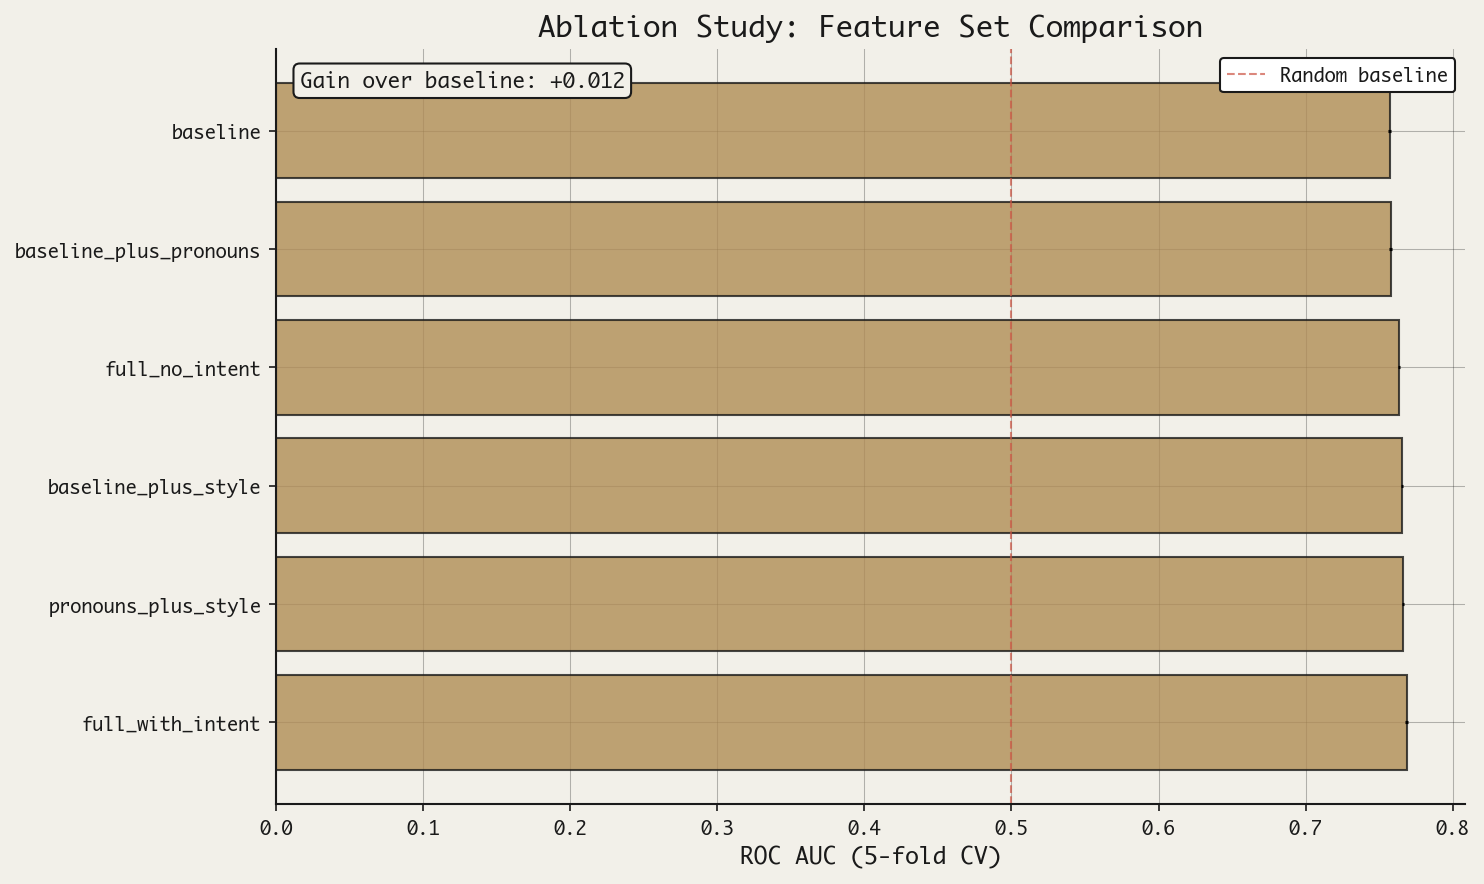


Ablation study complete. Best feature set identified.


In [16]:
# ============================================================
# Ablation Study on Training Data (EXPLORATORY)
# ============================================================

def run_ablation_study(train_df: pl.DataFrame, feature_sets: dict, outcome_col: str, n_splits: int = 5):
    """
    Run cross-validated ablation study on training data.
    Returns AUC for each feature set.
    """
    results = []
    
    for set_name, feature_cols in feature_sets.items():
        print(f"\nEvaluating {set_name}...")
        
        # Check if all features exist
        missing = [f for f in feature_cols if f not in train_df.columns]
        if missing:
            print(f"  Warning: Missing features: {missing}")
            feature_cols = [f for f in feature_cols if f in train_df.columns]
        
        if len(feature_cols) == 0:
            print(f"  Skipping {set_name}: No valid features")
            continue
        
        X, y = build_feature_matrix(train_df, feature_cols, outcome_col)
        
        # Cross-validate
        fold_aucs = cross_validate_auc(X, y, n_splits)
        
        results.append({
            'feature_set': set_name,
            'n_features': len(feature_cols),
            'mean_auc': np.mean(fold_aucs),
            'std_auc': np.std(fold_aucs),
            'features': feature_cols
        })
        
        print(f"  AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
    
    return pl.DataFrame(results).sort('mean_auc', descending=True)

# Prepare training data
print("="*70)
print("ABLATION STUDY (EXPLORATORY - Training Data Only)")
print("="*70)

train_df = first_turn_features.filter(pl.col('user_id').is_in(train_user_ids))
outcome_col = f'returned_{FOLLOWUP_DAYS}d'

print(f"\nTraining data: {len(train_df):,} conversations")
print(f"Outcome: {outcome_col}")
print(f"Return rate: {100 * train_df[outcome_col].mean():.1f}%")

# Run ablation study
print("\nRunning 5-fold cross-validation for each feature set...")
ablation_results = run_ablation_study(train_df, FEATURE_SETS, outcome_col, n_splits=5)

# Display results
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)
print(f"\n{'Feature Set':<30} {'N Features':<12} {'Mean AUC':<12} {'Std AUC':<12}")
print("-"*70)
for row in ablation_results.iter_rows(named=True):
    print(f"{row['feature_set']:<30} {row['n_features']:>11} {row['mean_auc']:>11.3f} {row['std_auc']:>11.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

sets = ablation_results['feature_set'].to_list()
aucs = ablation_results['mean_auc'].to_list()
stds = ablation_results['std_auc'].to_list()

y_pos = np.arange(len(sets))
ax.barh(y_pos, aucs, xerr=stds, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(sets)
ax.set_xlabel('ROC AUC (5-fold CV)', fontsize=11)
ax.set_title('Ablation Study: Feature Set Comparison', fontsize=14, fontweight='bold', color=BRAND['ink'])
ax.axvline(x=0.5, color=BRAND['alert'], linestyle='--', linewidth=1, alpha=0.7, label='Random baseline')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# Annotate incremental gains
best_auc = max(aucs)
baseline_auc = aucs[sets.index('baseline')] if 'baseline' in sets else None
if baseline_auc:
    gain = best_auc - baseline_auc
    ax.text(0.02, 0.95, f'Gain over baseline: +{gain:.3f}', 
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor=BRAND['paper'], edgecolor=BRAND['ink']))

apply_phronos_style(ax)
plt.tight_layout()
save_figure(fig, 'ablation_study')
plt.show()

print("\n" + "="*70)
print("Ablation study complete. Best feature set identified.")
print("="*70)



Using best feature set from ablation: full_with_intent
Features (13): word_count, first_person_singular_rate, first_person_plural_rate, second_person_rate, politeness_rate, has_question, is_imperative, avg_word_length, is_greeting, intent_coding, intent_roleplay, intent_creative_writing, intent_emotional_support
Type of best_features: <class 'list'>

Debug: Feature matrix shape: X=(1822387, 13), y=(1822387,)
RANDOM FEATURE COMPARISON

Evaluating real features...
Evaluating random features...
Evaluating real + random features...

----------------------------------------------------------------------
RESULTS
----------------------------------------------------------------------
Real features only:     AUC = 0.769 ± 0.001
Random features only:   AUC = 0.501 ± 0.001
Real + random:          AUC = 0.769 ± 0.001

Real vs Random t-test: t=450.51, p=0.0000
✓ Real features significantly outperform random (p < 0.05)
Saved: ../outputs/figures/pub_random_feature_comparison.png


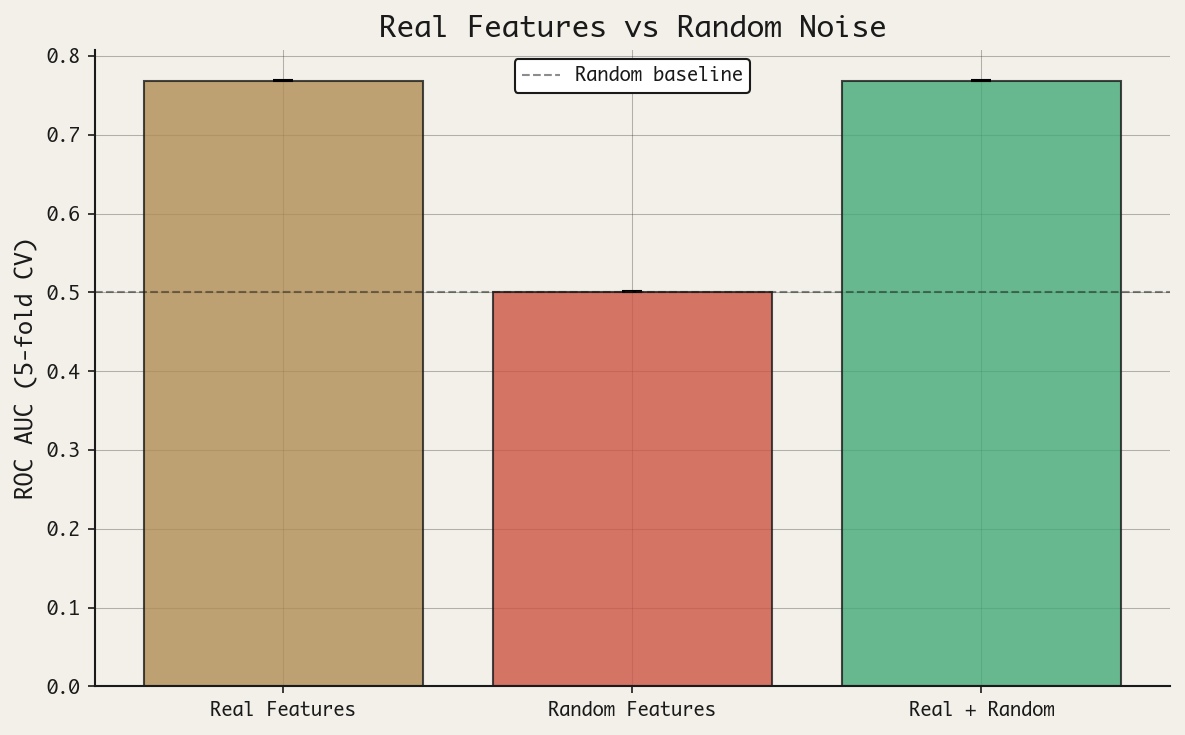

In [17]:
# ============================================================
# Random Feature Comparison
# ============================================================

def compare_to_random_features(train_df: pl.DataFrame, real_features: list, outcome_col: str, 
                                n_random: int = 5, n_splits: int = 5):
    """
    Compare real feature performance to random noise features.
    This guards against overfitting to noise.
    """
    print("="*70)
    print("RANDOM FEATURE COMPARISON")
    print("="*70)
    
    X_real, y = build_feature_matrix(train_df, real_features, outcome_col)
    
    # Add random features
    np.random.seed(RANDOM_STATE)
    X_random = np.random.randn(X_real.shape[0], n_random)
    
    # Model with real features only
    print("\nEvaluating real features...")
    real_aucs = cross_validate_auc(X_real, y, n_splits)
    
    # Model with random features only
    print("Evaluating random features...")
    random_aucs = cross_validate_auc(X_random, y, n_splits)
    
    # Model with real + random features
    print("Evaluating real + random features...")
    X_combined = np.hstack([X_real, X_random])
    combined_aucs = cross_validate_auc(X_combined, y, n_splits)
    
    print("\n" + "-"*70)
    print("RESULTS")
    print("-"*70)
    print(f"Real features only:     AUC = {np.mean(real_aucs):.3f} ± {np.std(real_aucs):.3f}")
    print(f"Random features only:   AUC = {np.mean(random_aucs):.3f} ± {np.std(random_aucs):.3f}")
    print(f"Real + random:          AUC = {np.mean(combined_aucs):.3f} ± {np.std(combined_aucs):.3f}")
    
    # Statistical test: real > random?
    t_stat, p_value = stats.ttest_ind(real_aucs, random_aucs)
    print(f"\nReal vs Random t-test: t={t_stat:.2f}, p={p_value:.4f}")
    
    if p_value < 0.05:
        print("✓ Real features significantly outperform random (p < 0.05)")
    else:
        print("⚠ Warning: Real features do not significantly outperform random")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(8, 5))
    
    categories = ['Real Features', 'Random Features', 'Real + Random']
    means = [np.mean(real_aucs), np.mean(random_aucs), np.mean(combined_aucs)]
    stds = [np.std(real_aucs), np.std(random_aucs), np.std(combined_aucs)]
    
    bars = ax.bar(categories, means, yerr=stds, color=[BRAND['gold'], BRAND['alert'], BRAND['success']], 
                  edgecolor=BRAND['ink'], alpha=0.8, capsize=5)
    ax.axhline(y=0.5, color=BRAND['ink'], linestyle='--', linewidth=1, alpha=0.5, label='Random baseline')
    ax.set_ylabel('ROC AUC (5-fold CV)', fontsize=11)
    ax.set_title('Real Features vs Random Noise', fontsize=14, fontweight='bold', color=BRAND['ink'])
    ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
    
    apply_phronos_style(ax)
    plt.tight_layout()
    save_figure(fig, 'random_feature_comparison')
    plt.show()
    
    return {
        'real_auc': np.mean(real_aucs),
        'random_auc': np.mean(random_aucs),
        'combined_auc': np.mean(combined_aucs),
        'p_value': p_value
    }

# Use best feature set from ablation (or full_with_intent)
best_feature_set = ablation_results['feature_set'][0]  # Already sorted by AUC
best_features_row = ablation_results.filter(pl.col('feature_set') == best_feature_set)

# Extract features list properly - get the first (and only) row's features
best_features = best_features_row['features'].to_list()[0]

# Ensure it's a list (handle case where it might be stored differently)
if not isinstance(best_features, list):
    import ast
    if isinstance(best_features, str):
        try:
            best_features = ast.literal_eval(best_features)
        except:
            best_features = [best_features]
    else:
        best_features = list(best_features)

print(f"\nUsing best feature set from ablation: {best_feature_set}")
print(f"Features ({len(best_features)}): {', '.join(best_features)}")
print(f"Type of best_features: {type(best_features)}")

# Verify all features exist in train_df
missing = [f for f in best_features if f not in train_df.columns]
if missing:
    print(f"WARNING: Missing features: {missing}")
    best_features = [f for f in best_features if f in train_df.columns]
    print(f"Using {len(best_features)} available features")

# Debug: Check feature matrix shape before calling compare_to_random_features
X_test, y_test = build_feature_matrix(train_df, best_features, outcome_col)
print(f"\nDebug: Feature matrix shape: X={X_test.shape}, y={y_test.shape}")
if X_test.shape[0] != y_test.shape[0]:
    raise ValueError(f"Shape mismatch detected: X has {X_test.shape[0]} rows, y has {y_test.shape[0]} rows. "
                    f"X shape: {X_test.shape}, y shape: {y_test.shape}, n_features: {len(best_features)}")

random_comparison = compare_to_random_features(train_df, best_features, outcome_col, n_random=5, n_splits=5)

print("\n" + "="*70)


PERMUTATION IMPORTANCE ANALYSIS

Computing permutation importance (n_repeats=10)...

----------------------------------------------------------------------
FEATURE IMPORTANCE (Permutation)
----------------------------------------------------------------------

Feature                        Importance      Std            
----------------------------------------------------------------------
word_count                             0.2309         0.0003
intent_roleplay                        0.0096         0.0001
avg_word_length                        0.0066         0.0001
intent_emotional_support               0.0021         0.0000
is_greeting                            0.0014         0.0000
has_question                           0.0011         0.0001
intent_creative_writing                0.0010         0.0000
politeness_rate                        0.0004         0.0000
is_imperative                          0.0001         0.0000
first_person_singular_rate             0.0001         0.

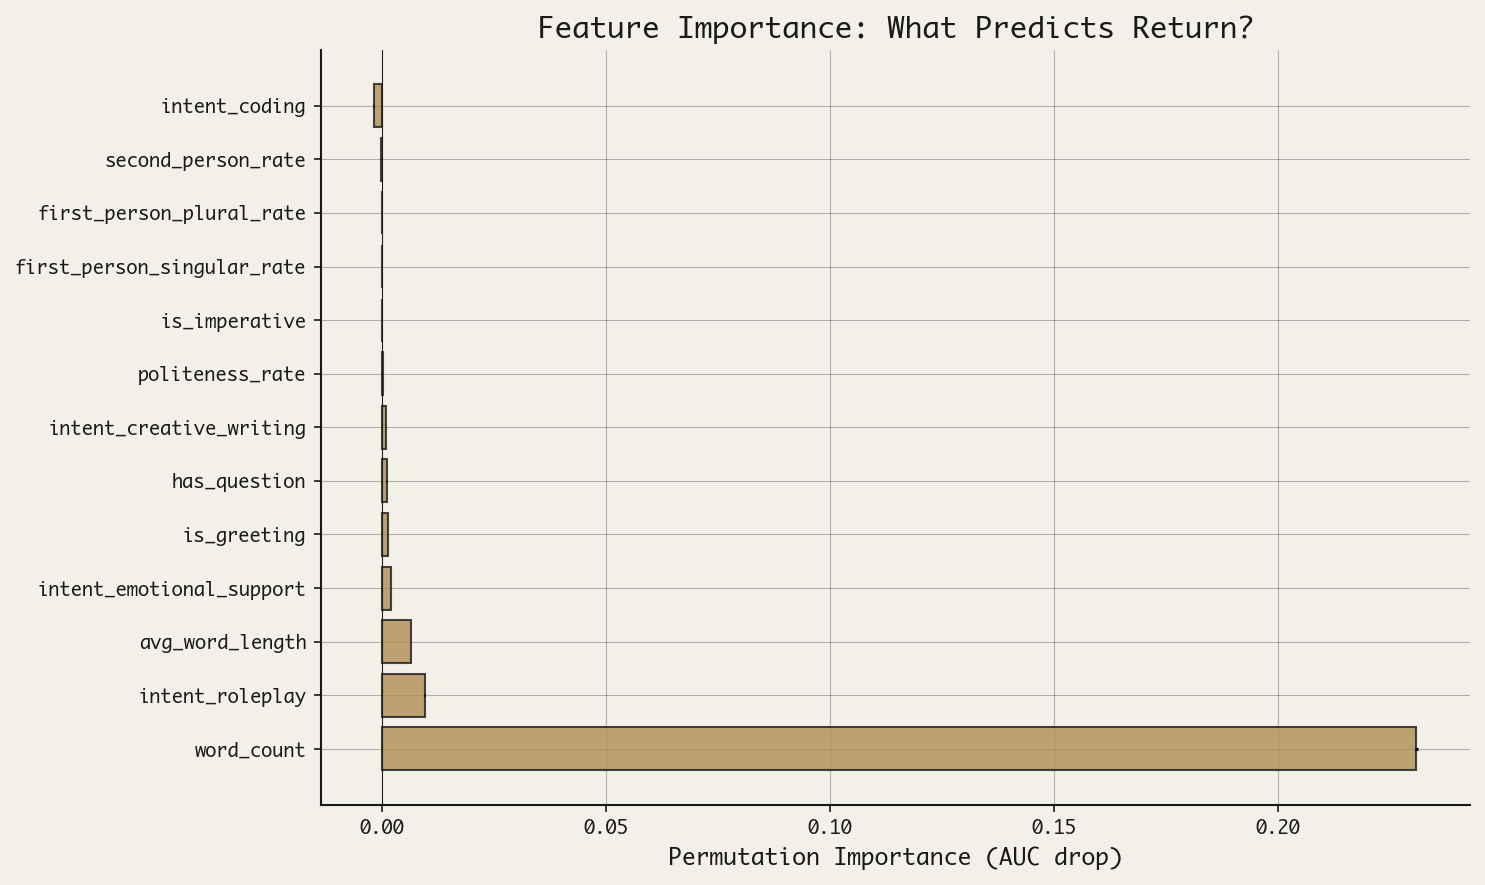

In [18]:
# ============================================================
# Permutation Importance
# ============================================================

def compute_permutation_importance(model, X: np.ndarray, y: np.ndarray, feature_names: list, n_repeats: int = 10):
    """
    Compute permutation importance for each feature.
    Features where permutation hurts most are most important.
    """
    result = permutation_importance(
        model, X, y, 
        n_repeats=n_repeats, 
        random_state=RANDOM_STATE,
        scoring='roc_auc'
    )
    
    importance_df = pl.DataFrame({
        'feature': feature_names,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort('importance_mean', descending=True)
    
    return importance_df

print("="*70)
print("PERMUTATION IMPORTANCE ANALYSIS")
print("="*70)

# Fit final model on training data for importance computation
X_train, y_train = build_feature_matrix(train_df, best_features, outcome_col)
scaler_importance = StandardScaler()
X_train_scaled = scaler_importance.fit_transform(X_train)

model_importance = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
model_importance.fit(X_train_scaled, y_train)

print(f"\nComputing permutation importance (n_repeats=10)...")
importance_df = compute_permutation_importance(
    model_importance, X_train_scaled, y_train, 
    best_features
)

print("\n" + "-"*70)
print("FEATURE IMPORTANCE (Permutation)")
print("-"*70)
print(f"\n{'Feature':<30} {'Importance':<15} {'Std':<15}")
print("-"*70)
for row in importance_df.iter_rows(named=True):
    print(f"{row['feature']:<30} {row['importance_mean']:>14.4f} {row['importance_std']:>14.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

features = importance_df['feature'].to_list()
importances = importance_df['importance_mean'].to_list()
stds = importance_df['importance_std'].to_list()

y_pos = np.arange(len(features))
ax.barh(y_pos, importances, xerr=stds, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel('Permutation Importance (AUC drop)', fontsize=11)
ax.set_title('Feature Importance: What Predicts Return?', fontsize=14, fontweight='bold', color=BRAND['ink'])
ax.axvline(x=0, color=BRAND['ink'], linestyle='-', linewidth=0.5)

apply_phronos_style(ax)
plt.tight_layout()
save_figure(fig, 'feature_importance')
plt.show()

print("\n" + "="*70)


In [ ]:
# ============================================================
# Final Model Training on Full Training Data
# ============================================================

print("="*70)
print("FINAL MODEL TRAINING (Full Training Data)")
print("="*70)

# Select best feature set from ablation
FINAL_FEATURES = best_features

print(f"\nFeature set: {best_feature_set}")
print(f"Features ({len(FINAL_FEATURES)}): {', '.join(FINAL_FEATURES)}")

# Train on ALL training data (no cross-validation)
X_train_final, y_train_final = build_feature_matrix(train_df, FINAL_FEATURES, outcome_col)
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)

model_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
model_final.fit(X_train_final_scaled, y_train_final)

print(f"\nModel trained on {len(X_train_final):,} training samples")
print(f"Return rate in training: {100 * y_train_final.mean():.1f}%")

# Report coefficients
coef_df = pl.DataFrame({
    'feature': FINAL_FEATURES,
    'coefficient': model_final.coef_[0],
    'odds_ratio': np.exp(model_final.coef_[0])
}).sort('coefficient', descending=True)

print("\n" + "-"*70)
print("MODEL COEFFICIENTS")
print("-"*70)
print(f"\n{'Feature':<30} {'Coefficient':<15} {'Odds Ratio':<15}")
print("-"*70)
for row in coef_df.iter_rows(named=True):
    print(f"{row['feature']:<30} {row['coefficient']:>14.4f} {row['odds_ratio']:>14.4f}")

# Interpretation
print("\n" + "-"*70)
print("INTERPRETATION")
print("-"*70)
print("\nPositive coefficients increase probability of return:")
top_positive = coef_df.head(3)
for row in top_positive.iter_rows(named=True):
    print(f"  {row['feature']}: OR = {row['odds_ratio']:.3f} (1 unit increase → {100*(row['odds_ratio']-1):.1f}% increase in odds)")

print("\nNegative coefficients decrease probability of return:")
top_negative = coef_df.tail(3)
for row in top_negative.iter_rows(named=True):
    print(f"  {row['feature']}: OR = {row['odds_ratio']:.3f} (1 unit increase → {100*(1-row['odds_ratio']):.1f}% decrease in odds)")

print("\n" + "="*70)
print("Final model ready for confirmatory testing.")
print("="*70)


In [ ]:
# ============================================================
# CONFIRMATORY TEST on Held-Out Test Set
# ============================================================
# CRITICAL: Run ONLY ONCE after all exploratory work is complete.

print("="*70)
print("CONFIRMATORY ANALYSIS: HELD-OUT TEST SET (NEW USERS ONLY)")
print("="*70)
print("\n⚠️  This is the honest evaluation. Run this cell EXACTLY ONCE.")
print("   Any peeking at test data before this point contaminates the analysis.\n")

# Build test features
test_df = first_turn_features.filter(pl.col('user_id').is_in(test_user_ids))
X_test, y_test = build_feature_matrix(test_df, FINAL_FEATURES, outcome_col)
X_test_scaled = scaler_final.transform(X_test)

print(f"Test Set Size: {len(y_test):,} new users")
print(f"Test Set Return Rate: {100*y_test.mean():.1f}%")

# Predict
y_pred_prob = model_final.predict_proba(X_test_scaled)[:, 1]
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Metrics
test_auc = roc_auc_score(y_test, y_pred_prob)

print("\n" + "="*70)
print("TEST SET PERFORMANCE")
print("="*70)
print(f"\nROC AUC: {test_auc:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_class, target_names=['Did not return', 'Returned']))

# Calibration check
print("\n" + "-"*70)
print("CALIBRATION CHECK")
print("-"*70)
print("Predicted vs Actual Return Rates by Probability Bin:")
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    mask = (y_pred_prob >= threshold - 0.05) & (y_pred_prob < threshold + 0.05)
    if mask.sum() > 0:
        actual_rate = y_test[mask].mean()
        predicted_rate = y_pred_prob[mask].mean()
        print(f"  Predicted ~{threshold:.0%}: Actual {actual_rate:.1%} (n={mask.sum():,}, diff={abs(predicted_rate-actual_rate):.1%})")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confirmatory Test Results (Held-Out Test Set)', 
             fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax = axes[0]
ax.plot(fpr, tpr, color=BRAND['gold'], linewidth=2, label=f'Model (AUC={test_auc:.3f})')
ax.plot([0, 1], [0, 1], color=BRAND['ink'], linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

# Panel 2: Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
ax = axes[1]
ax.plot(prob_pred, prob_true, color=BRAND['gold'], marker='o', linewidth=2, markersize=6, label='Model')
ax.plot([0, 1], [0, 1], color=BRAND['ink'], linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Curve', fontsize=12, fontweight='bold')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

# Panel 3: Prediction distribution
ax = axes[2]
ax.hist(y_pred_prob[y_test == 0], bins=30, alpha=0.7, color=BRAND['ink'], label='Did not return', density=True)
ax.hist(y_pred_prob[y_test == 1], bins=30, alpha=0.7, color=BRAND['gold'], label='Returned', density=True)
ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Prediction Distribution by Outcome', fontsize=12, fontweight='bold')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'test_set_results')
plt.show()

print("\n" + "="*70)
print("CONFIRMATORY TEST COMPLETE")
print("="*70)
print(f"\nKey Result: Test AUC = {test_auc:.3f}")
print("\nThis is the honest evaluation on held-out data.")
print("Compare to training CV AUC to assess overfitting.")
print("="*70)


DESCRIPTIVE ANALYSIS: INTENT DIVERSITY AND ENGAGEMENT

Note: This is DESCRIPTIVE only. Intent diversity cannot be used to predict
engagement because it requires multiple conversations to measure.

⚠️  Analysis limited to TRAINING DATA ONLY (users with first conv < cutoff).
⚠️  Analysis limited to users with 2+ conversations (~20% of dataset).
   One-shot users (~80%) are excluded.

Training users with 5+ conversations: 58,288

----------------------------------------------------------------------
INTENT DIVERSITY BY ENGAGEMENT LEVEL
----------------------------------------------------------------------
Moderate (5-20): entropy = 0.02 ± 0.11 (n=1,932)
Heavy (21-99): entropy = 0.02 ± 0.12 (n=329)
Power (100+): entropy = 0.02 ± 0.16 (n=187)
Saved: ../outputs/figures/pub_intent_diversity_characterization.png


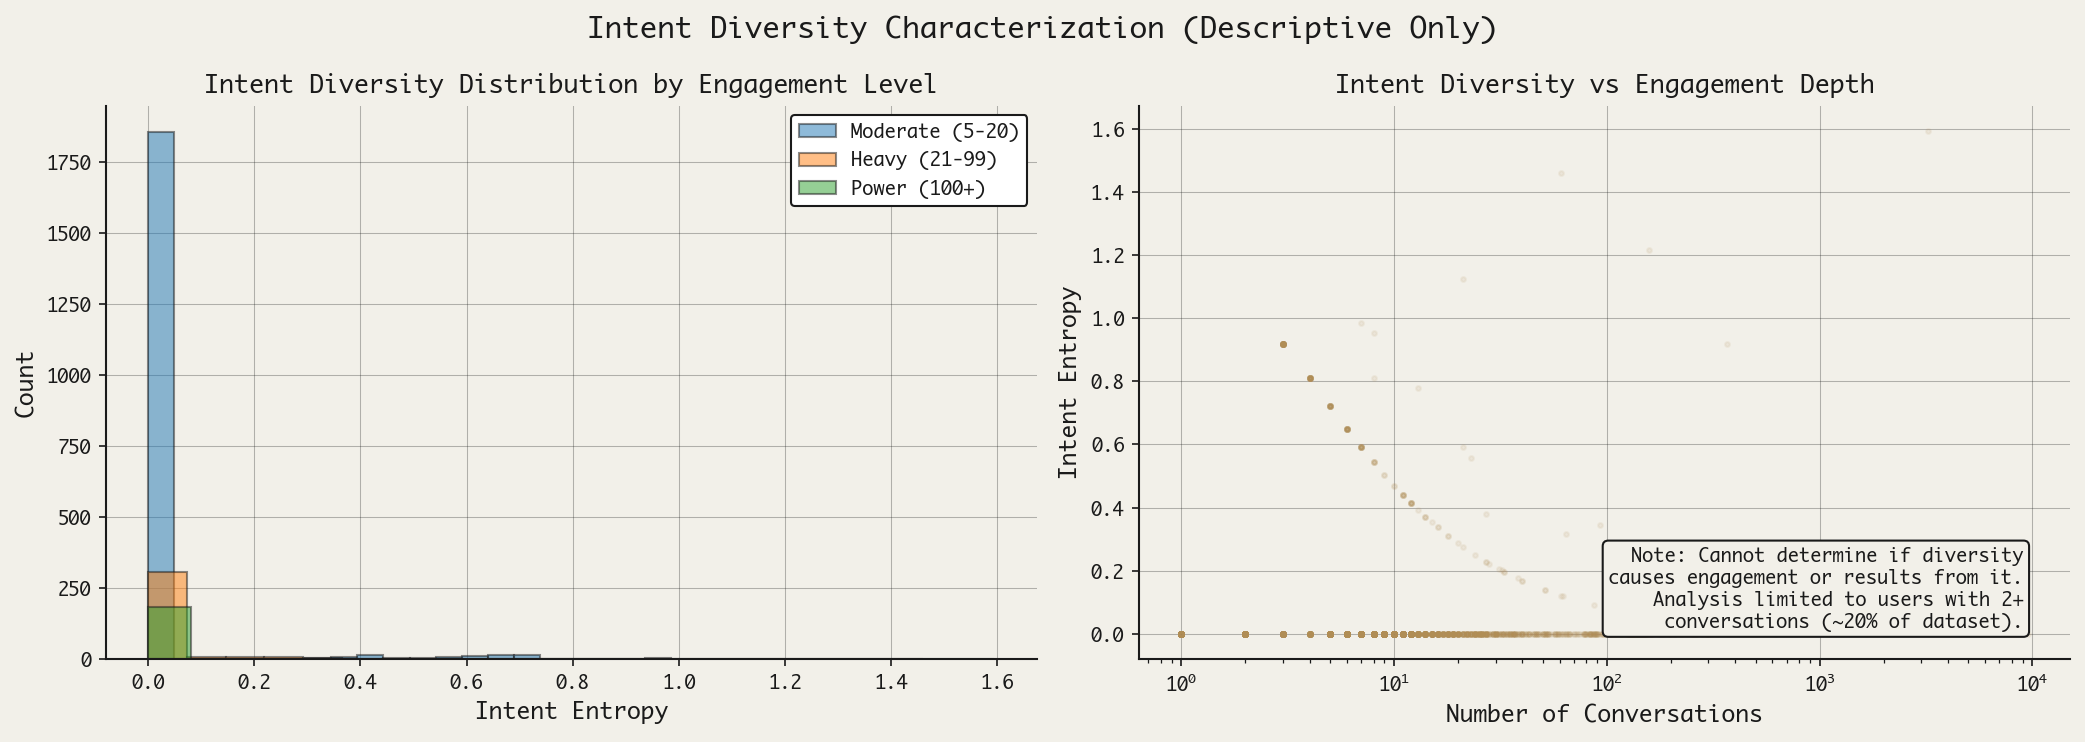


PRONOUN FEATURE DESCRIPTIVE STATISTICS (Training Data)

Pronoun Features (n=156,905 conversations from engaged training users):
  First-person singular rate: 0.305 ± 1.658
  First-person plural rate:   0.053 ± 0.494
  Second-person rate:         0.516 ± 2.451

----------------------------------------------------------------------
PRONOUN FEATURES BY ENGAGEMENT LEVEL (Training Data)
----------------------------------------------------------------------

Moderate (5-20) (n=1,932 users, 15,769 conversations):
  First-person singular: 0.117
  First-person plural:   0.045
  Second-person:         0.709

Heavy (21-99) (n=329 users, 14,072 conversations):
  First-person singular: 0.048
  First-person plural:   0.044
  Second-person:         0.266

Power (100+) (n=187 users, 72,686 conversations):
  First-person singular: 0.052
  First-person plural:   0.012
  Second-person:         0.316

Intent diversity analysis complete (descriptive only).


In [20]:
# ============================================================
# Intent Diversity as Descriptive Characterization
# ============================================================
# Purpose: Characterize (not predict) relationship between intent diversity and engagement
# Note: This analysis is limited to users who returned at least once (have 2+ conversations).
#       Most users (one-shot) are excluded, so results describe only the engaged subset.

import math
from collections import Counter

def compute_intent_entropy(intents):
    """Compute Shannon entropy of intent distribution."""
    counts = Counter(intents)
    total = sum(counts.values())
    if total <= 1:
        return 0.0
    return -sum((c/total) * math.log2(c/total) for c in counts.values() if c > 0)

print("="*70)
print("DESCRIPTIVE ANALYSIS: INTENT DIVERSITY AND ENGAGEMENT")
print("="*70)
print("\nNote: This is DESCRIPTIVE only. Intent diversity cannot be used to predict")
print("engagement because it requires multiple conversations to measure.")
print("\n⚠️  Analysis limited to TRAINING DATA ONLY (users with first conv < cutoff).")
print("⚠️  Analysis limited to users with 2+ conversations (~20% of dataset).")
print("   One-shot users (~80%) are excluded.\n")

# Filter to training data only
train_user_outcomes = user_outcomes.filter(pl.col('user_id').is_in(train_user_ids))
train_first_turn_features = first_turn_features.filter(pl.col('user_id').is_in(train_user_ids))

# Compute diversity for users with 5+ conversations (for meaningful entropy)
engaged_users = train_user_outcomes.filter(pl.col('n_conversations') >= 5)

print(f"Training users with 5+ conversations: {len(engaged_users):,}")

# For each user, get their intent distribution across conversations
# Join with first_turn_features to get intents (training data only)
user_intents_raw = train_first_turn_features.filter(
    pl.col('user_id').is_in(engaged_users['user_id'].to_list())
).group_by('user_id').agg([
    pl.col('intent').alias('intents'),
    pl.len().alias('n_conversations')
])

# Compute entropy
user_intents = user_intents_raw.with_columns([
    pl.col('intents').map_elements(compute_intent_entropy, return_dtype=pl.Float64).alias('intent_entropy')
])

# Compare across engagement levels
engagement_tiers = [
    ('Moderate (5-20)', 5, 20),
    ('Heavy (21-99)', 21, 99),
    ('Power (100+)', 100, float('inf'))
]

print("\n" + "-"*70)
print("INTENT DIVERSITY BY ENGAGEMENT LEVEL")
print("-"*70)
for tier_name, min_conv, max_conv in engagement_tiers:
    tier_data = user_intents.filter(
        (pl.col('n_conversations') >= min_conv) & 
        (pl.col('n_conversations') <= max_conv)
    )
    if len(tier_data) > 0:
        mean_entropy = tier_data['intent_entropy'].mean()
        std_entropy = tier_data['intent_entropy'].std()
        n_users = len(tier_data)
        print(f"{tier_name}: entropy = {mean_entropy:.2f} ± {std_entropy:.2f} (n={n_users:,})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Intent Diversity Characterization (Descriptive Only)', 
             fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Entropy distribution by engagement tier
ax = axes[0]
for tier_name, min_conv, max_conv in engagement_tiers:
    tier_data = user_intents.filter(
        (pl.col('n_conversations') >= min_conv) & 
        (pl.col('n_conversations') <= max_conv)
    )
    if len(tier_data) > 0:
        ax.hist(tier_data['intent_entropy'].to_numpy(), bins=20, alpha=0.5, 
                label=tier_name, edgecolor=BRAND['ink'])

ax.set_xlabel('Intent Entropy', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Intent Diversity Distribution by Engagement Level', fontsize=12, fontweight='bold')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

# Panel 2: Scatter plot - conversations vs entropy
ax = axes[1]
ax.scatter(
    user_intents['n_conversations'].to_numpy(), 
    user_intents['intent_entropy'].to_numpy(),
    alpha=0.1, color=BRAND['gold'], s=5
)
ax.set_xlabel('Number of Conversations', fontsize=11)
ax.set_ylabel('Intent Entropy', fontsize=11)
ax.set_title('Intent Diversity vs Engagement Depth', fontsize=12, fontweight='bold')
ax.set_xscale('log')
apply_phronos_style(ax)

# Add annotation about directionality
ax.annotate(
    'Note: Cannot determine if diversity\ncauses engagement or results from it.\nAnalysis limited to users with 2+\nconversations (~20% of dataset).',
    xy=(0.95, 0.05), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=9,
    bbox=dict(boxstyle='round', facecolor=BRAND['paper'], edgecolor=BRAND['ink'])
)

plt.tight_layout()
save_figure(fig, 'intent_diversity_characterization')
plt.show()

# ============================================================
# Pronoun Feature Descriptive Statistics (Training Data)
# ============================================================
print("\n" + "="*70)
print("PRONOUN FEATURE DESCRIPTIVE STATISTICS (Training Data)")
print("="*70)

# Get pronoun features for engaged users (training data only)
engaged_features = train_first_turn_features.filter(
    pl.col('user_id').is_in(engaged_users['user_id'].to_list())
)

# Check which pronoun columns exist
pronoun_cols = []
for col in ['first_person_singular_rate', 'first_person_plural_rate', 'second_person_rate']:
    if col in engaged_features.columns:
        pronoun_cols.append(col)

if len(pronoun_cols) > 0:
    pronoun_aggs = [
        pl.col(col).mean().alias(f'mean_{col}') for col in pronoun_cols
    ] + [
        pl.col(col).std().alias(f'std_{col}') for col in pronoun_cols
    ] + [pl.len().alias('n_conversations')]
    
    pronoun_stats = engaged_features.select(pronoun_aggs).row(0, named=True)
    
    print(f"\nPronoun Features (n={pronoun_stats['n_conversations']:,} conversations from engaged training users):")
    
    if 'first_person_singular_rate' in pronoun_cols:
        print(f"  First-person singular rate: {pronoun_stats['mean_first_person_singular_rate']:.3f} ± {pronoun_stats['std_first_person_singular_rate']:.3f}")
    if 'first_person_plural_rate' in pronoun_cols:
        print(f"  First-person plural rate:   {pronoun_stats['mean_first_person_plural_rate']:.3f} ± {pronoun_stats['std_first_person_plural_rate']:.3f}")
    if 'second_person_rate' in pronoun_cols:
        print(f"  Second-person rate:         {pronoun_stats['mean_second_person_rate']:.3f} ± {pronoun_stats['std_second_person_rate']:.3f}")
    
    # Compare pronoun features across engagement tiers
    print("\n" + "-"*70)
    print("PRONOUN FEATURES BY ENGAGEMENT LEVEL (Training Data)")
    print("-"*70)
    
    for tier_name, min_conv, max_conv in engagement_tiers:
        tier_user_ids = user_intents.filter(
            (pl.col('n_conversations') >= min_conv) & 
            (pl.col('n_conversations') <= max_conv)
        )['user_id'].to_list()
        
        if len(tier_user_ids) > 0:
            tier_features = train_first_turn_features.filter(
                pl.col('user_id').is_in(tier_user_ids)
            )
            
            tier_aggs = [
                pl.col(col).mean().alias(f'mean_{col}') for col in pronoun_cols
            ] + [pl.len().alias('n_conv')]
            
            tier_pronoun_stats = tier_features.select(tier_aggs).row(0, named=True)
            
            print(f"\n{tier_name} (n={len(tier_user_ids):,} users, {tier_pronoun_stats['n_conv']:,} conversations):")
            if 'first_person_singular_rate' in pronoun_cols:
                print(f"  First-person singular: {tier_pronoun_stats['mean_first_person_singular_rate']:.3f}")
            if 'first_person_plural_rate' in pronoun_cols:
                print(f"  First-person plural:   {tier_pronoun_stats['mean_first_person_plural_rate']:.3f}")
            if 'second_person_rate' in pronoun_cols:
                print(f"  Second-person:         {tier_pronoun_stats['mean_second_person_rate']:.3f}")
else:
    print("\nNote: Pronoun rate columns not found in feature dataset.")
    print("Available columns:", engaged_features.columns)

print("\n" + "="*70)
print("Intent diversity analysis complete (descriptive only).")
print("="*70)


In [ ]:
# ============================================================
# Model-Version Sensitivity Analysis
# ============================================================
# Test whether findings hold within model versions to address temporal confounds

print("="*70)
print("SENSITIVITY ANALYSIS: WITHIN-MODEL-VERSION EFFECTS")
print("="*70)
print("\nTesting whether findings hold within each model family")
print("to address temporal confounds (better models over time).\n")

# Get model_family for training data
train_with_model = train_df.join(
    df_users.select(['conversation_hash', 'model_family']).unique(subset=['conversation_hash']),
    on='conversation_hash',
    how='left'
)

results_by_model = []

for model_family in ['GPT-3.5', 'GPT-4', 'GPT-4o']:
    model_train = train_with_model.filter(pl.col('model_family') == model_family)
    
    if len(model_train) < 1000:
        print(f"{model_family}: Insufficient data (n={len(model_train):,})")
        results_by_model.append({
            'model_family': model_family,
            'n_users': len(model_train),
            'return_rate': None,
            'auc_mean': None,
            'auc_std': None
        })
        continue
    
    X, y = build_feature_matrix(model_train, FINAL_FEATURES, outcome_col)
    
    # Cross-validated AUC
    aucs = cross_validate_auc(X, y, n_splits=5)
    
    print(f"{model_family}:")
    print(f"  N users: {len(model_train):,}")
    print(f"  Return rate: {100*y.mean():.1f}%")
    print(f"  AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    print()
    
    results_by_model.append({
        'model_family': model_family,
        'n_users': len(model_train),
        'return_rate': float(y.mean()),
        'auc_mean': float(np.mean(aucs)),
        'auc_std': float(np.std(aucs))
    })

# Visualize
if len([r for r in results_by_model if r['auc_mean'] is not None]) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    valid_results = [r for r in results_by_model if r['auc_mean'] is not None]
    models = [r['model_family'] for r in valid_results]
    aucs = [r['auc_mean'] for r in valid_results]
    stds = [r['auc_std'] for r in valid_results]
    
    ax.bar(models, aucs, yerr=stds, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8, capsize=5)
    ax.axhline(y=0.5, color=BRAND['ink'], linestyle='--', linewidth=1, alpha=0.5, label='Random baseline')
    ax.set_ylabel('ROC AUC (5-fold CV)', fontsize=11)
    ax.set_title('Model Performance by Model Family', fontsize=14, fontweight='bold', color=BRAND['ink'])
    ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
    
    apply_phronos_style(ax)
    plt.tight_layout()
    save_figure(fig, 'model_version_sensitivity')
    plt.show()

print("="*70)
print("Sensitivity analysis complete.")
print("="*70)


In [ ]:
# ============================================================
# Limitations and Recommendations
# ============================================================

limitations_text = """
METHODOLOGICAL LIMITATIONS:

1. ECOLOGICAL FALLACY: This analysis compares different people, not the same 
   person over time. Group-level patterns may not apply to individuals.

2. CORRELATION ≠ CAUSATION: Pronoun use, politeness, and other features may 
   be markers of underlying traits rather than causal factors.

3. REFERENCE CLASS: WildChat users (anonymous, 33% toxic content) may not 
   represent other AI user populations.

4. TEMPORAL CONFOUNDS: Better models over time enabled more diverse use cases.
   Intent diversity may reflect model capability, not user characteristics.

5. CENSORING: Users who started recently had less time to return. We addressed
   this with fixed time windows but some bias may remain.

RECOMMENDATIONS FOR PERSONAL INFERENCE:

1. DO NOT use this model to predict your own behavior. The individual-level
   prediction intervals are too wide to be actionable.

2. DESCRIPTIVE SELF-IDENTIFICATION is appropriate: "People with prompting 
   patterns similar to mine tend to [X]. I might share other characteristics
   with this group."

3. ALWAYS CONSIDER BASE RATES: Even the strongest predictors shift return 
   probability by only a few percentage points. Most users don't return 
   regardless of prompting style.

4. LOCATE YOURSELF IN SUBGROUPS: Effects vary by intent category and model.
   Find the comparison group most relevant to your use case.

5. THIS IS A MIRROR, NOT AN ORACLE: These patterns describe how people differ,
   not how you will behave.
"""

print("="*70)
print("LIMITATIONS AND RECOMMENDATIONS")
print("="*70)
print(limitations_text)

# Save to file
output_path = '../outputs/limitations_and_recommendations.txt'
with open(output_path, 'w') as f:
    f.write(limitations_text)

print(f"\nSaved to: {output_path}")
print("="*70)


In [ ]:
# ============================================================
# Output Summary
# ============================================================

print("="*70)
print("OUTPUT CHECKLIST")
print("="*70)

outputs = {
    'Figures': [
        'temporal_overview.png',
        'sample_size_calculator.png', 
        'ablation_study.png',
        'feature_importance.png',
        'test_set_results.png',
        'intent_diversity_characterization.png',
        'model_version_sensitivity.png',
        'random_feature_comparison.png'
    ],
    'Tables': [
        'Sample size by cutoff date',
        'Ablation study results',
        'Feature importance ranking',
        'Test set performance metrics',
        'Intent diversity by engagement tier',
        'Model coefficients and odds ratios'
    ],
    'Key Metrics': {
        'Training users': len(train_user_ids),
        'Test users (new only)': len(test_user_ids),
        'Train AUC (CV)': f"{ablation_results['mean_auc'][0]:.3f}" if len(ablation_results) > 0 else "N/A",
        'Test AUC (holdout)': f"{test_auc:.3f}" if 'test_auc' in dir() else "Not yet computed",
        'Best feature set': best_feature_set if 'best_feature_set' in dir() else "N/A",
        'Return rate (train)': f"{100 * train_df[outcome_col].mean():.1f}%" if 'train_df' in dir() else "N/A",
        'Return rate (test)': f"{100 * y_test.mean():.1f}%" if 'y_test' in dir() else "Not yet computed",
    }
}

for category, items in outputs.items():
    print(f"\n{category}:")
    if isinstance(items, list):
        for item in items:
            print(f"  - {item}")
    elif isinstance(items, dict):
        for k, v in items.items():
            print(f"  - {k}: {v}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print("\nAll outputs saved to ../outputs/figures/ and ../outputs/")
print("Review limitations_and_recommendations.txt for interpretation guidelines.")
print("="*70)
